In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scvi
import seaborn as sb
import anndata
import os

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


In [2]:
os.chdir("/home/lixiangyu/zr/Annotate/")

### Abdominal Aortic Aneurysm (AAA)

#### 1-JD 16450 15151

In [2]:
adata = sc.read_10x_mtx(
    '/home/lixiangyu/zr/Annotate/data/self_data_human/1-JD',  
    var_names='gene_symbols',             
    cache=True) 
#adata.obs['dataset'] = 'Alsaigh_filtered'

In [3]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 16450 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [6]:
# include dataset column
adata.obs["dataset"] = "1_JD"
# include symptom column
adata.obs["symptoms"] = 'not stated'

In [7]:
adata

AnnData object with n_obs × n_vars = 16450 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [8]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/1-JD/output/1_JD.h5ad")

In [7]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/1-JD/output/1_JD.h5ad")

In [8]:
# include dataset column
adata.obs["sample"] = "1_JD"
adata.obs["dataset"] = "1_JD"
# include symptom column
adata.obs["symptoms"] = 'Abdominal Aortic Aneurysm(AAA)'
adata

AnnData object with n_obs × n_vars = 16450 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [9]:
adata.obs["gender"] = "Unknown"
adata.obs["age"] = "Unknown"
adata.obs["intervention"] = "Unknown"
adata.obs["tissue"] = "Abdominal Aorta"
adata

AnnData object with n_obs × n_vars = 16450 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'gender', 'age', 'intervention', 'tissue'
    var: 'gene_ids', 'feature_types'

In [11]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/1-JD/output/1_JD_FM.h5ad")

In [9]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

/tmp/ipykernel_2762775/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [16]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/1-JD/output/1_JD.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/1-JD/output/1_JD_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~13160 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 2942 cells excluded from training.
iter=1, 3007 cells excluded from training.
iter=2, 2946 cells excluded from training.
Threshold found:0.452
2279 (13.9%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 13:38:46 2025 .. Analyzing all cells
Mon Dec 29 13:38:46 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 13:39:25 2025 .... Estimating contamination
Mon Dec 29 13:39:31 2025 ...... Completed iteration: 10 | converge: 0.03129
Mon Dec 29 13:39:36 2025 ...... Completed iteration: 20 | converge: 0.01219
Mon Dec 29 13:39:41 2025 ...... Completed iteration: 30 | converge: 0.006489
Mon Dec 29 13:39:46 2025 ...... Completed iteration: 40 | converge: 0.004571
Mon Dec 29 13:39:51 2025 ...... Completed iteration: 50 | converge: 0.003221
Mon Dec 29 13:39:56 2025 ...... Completed iter

In [17]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/1-JD/output/1_JD_postR.h5ad")

In [18]:
adata

AnnData object with n_obs × n_vars = 16450 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [19]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [20]:
sc.pp.filter_cells(adata, min_genes=0) # to get n_genes

In [21]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  # according to paper
sc.pp.filter_cells(adata, max_genes = 4000)  # according to paper
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000) #acc to author
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15]  # according to paper
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 16450
Number of cells after filter: 16237
Number of cells before MT filter: 16174
Number of cells after MT filter: 15151


In [88]:
#results_file = "../data/Plaque-datasets/Alsaigh/alsaigh_pp.h5ad"

In [22]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]

/tmp/ipykernel_2491686/986662564.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


In [23]:
adata

AnnData object with n_obs × n_vars = 15151 × 21836
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [24]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/1-JD/output/1_JD_postQC.h5ad")

#### 2_ZDZJ 17105 15891

In [29]:
adata = sc.read_10x_mtx(
    '/home/lixiangyu/zr/Annotate/data/self_data_human/2-ZDZJ', 
    var_names='gene_symbols',             
    cache=True) 


In [30]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 17105 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [31]:
# include dataset column
adata.obs["dataset"] = "2_ZDZJ"
# include symptom column
adata.obs["symptoms"] = 'not stated'

In [32]:
adata

AnnData object with n_obs × n_vars = 17105 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [33]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/2-ZDZJ/output/2_ZDZJ.h5ad")

In [34]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_2762775/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [25]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/2-ZDZJ/output/2_ZDZJ.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/2-ZDZJ/output/2_ZDZJ_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~13684 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 3141 cells excluded from training.
iter=1, 3056 cells excluded from training.
iter=2, 2921 cells excluded from training.
Threshold found:0.41
2174 (12.7%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 13:44:56 2025 .. Analyzing all cells
Mon Dec 29 13:44:56 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 13:45:38 2025 .... Estimating contamination
Mon Dec 29 13:45:44 2025 ...... Completed iteration: 10 | converge: 0.03671
Mon Dec 29 13:45:49 2025 ...... Completed iteration: 20 | converge: 0.02046
Mon Dec 29 13:45:54 2025 ...... Completed iteration: 30 | converge: 0.01373
Mon Dec 29 13:45:59 2025 ...... Completed iteration: 40 | converge: 0.008004
Mon Dec 29 13:46:04 2025 ...... Completed iteration: 50 | converge: 0.005419
Mon Dec 29 13:46:10 2025 ...... Completed iterat

In [26]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/2-ZDZJ/output/2_ZDZJ_postR.h5ad")

In [27]:
adata

AnnData object with n_obs × n_vars = 17105 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [28]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [29]:
sc.pp.filter_cells(adata, min_genes=0) # to get n_genes

In [30]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 17105


Number of cells after filter: 16940
Number of cells before MT filter: 16903
Number of cells after MT filter: 15891


In [103]:
#results_file = "../data/Plaque-datasets/Alsaigh/alsaigh_pp.h5ad"

In [31]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]

/tmp/ipykernel_2491686/986662564.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


In [32]:
adata

AnnData object with n_obs × n_vars = 15891 × 21075
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [33]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/2-ZDZJ/output/2_ZDZJ_postQC.h5ad")

#### AAA 11411 8779

In [47]:
adata = sc.read_10x_mtx(
    '/home/lixiangyu/zr/Annotate/data/self_data_human/AAA', 
    var_names='gene_symbols',             
    cache=True) 

In [48]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 11411 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [49]:
# include dataset column
adata.obs["dataset"] = "AAA"
# include symptom column
adata.obs["symptoms"] = 'not stated'

In [50]:
adata

AnnData object with n_obs × n_vars = 11411 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [51]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA/output/AAA.h5ad")

In [52]:
#start with double removal and ambient RNA correction 
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro 
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate

%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [34]:
%%R
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA/output/AAA.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA/output/AAA_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~9129 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 2068 cells excluded from training.
iter=1, 2082 cells excluded from training.
iter=2, 2049 cells excluded from training.
Threshold found:0.45
1156 (10.1%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 13:54:46 2025 .. Analyzing all cells
Mon Dec 29 13:54:46 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 13:55:14 2025 .... Estimating contamination
Mon Dec 29 13:55:19 2025 ...... Completed iteration: 10 | converge: 0.03001
Mon Dec 29 13:55:23 2025 ...... Completed iteration: 20 | converge: 0.009151
Mon Dec 29 13:55:27 2025 ...... Completed iteration: 30 | converge: 0.004638
Mon Dec 29 13:55:32 2025 ...... Completed iteration: 40 | converge: 0.002827
Mon Dec 29 13:55:36 2025 ...... Completed iteration: 50 | converge: 0.001755
Mon Dec 29 13:55:40 2025 ...... Completed itera

In [35]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA/output/AAA_postR.h5ad")

In [36]:
adata

AnnData object with n_obs × n_vars = 11411 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [37]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [38]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 11411
Number of cells after filter: 10331
Number of cells before MT filter: 10168
Number of cells after MT filter: 8779


In [39]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]

/tmp/ipykernel_2491686/986662564.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


In [40]:
adata

AnnData object with n_obs × n_vars = 8779 × 21908
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [41]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA/output/AAA_postQC.h5ad")

In [5]:
adata =sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA/output/AAA_postQC.h5ad")
adata

AnnData object with n_obs × n_vars = 8779 × 21908
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'raw_decontXcounts', 'uncorrected_counts'

#### AAA-1-3LIB 13065 11551

In [61]:
adata = sc.read_10x_mtx(
    '/home/lixiangyu/zr/Annotate/data/self_data_human/AAA-1-3LIB', 
    var_names='gene_symbols',             
    cache=True) 

In [62]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 13065 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [63]:
# include dataset column
adata.obs["dataset"] = "AAA-1-3LIB"
# include symptom column
adata.obs["symptoms"] = 'not stated'

In [64]:
adata

AnnData object with n_obs × n_vars = 13065 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [65]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-1-3LIB/output/AAA-1-3LIB.h5ad")

In [66]:
#start with double removal and ambient RNA correction 
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro 
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate

%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [42]:
%%R
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-1-3LIB/output/AAA-1-3LIB.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-1-3LIB/output/AAA-1-3LIB_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~10452 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 2478 cells excluded from training.
iter=1, 2435 cells excluded from training.
iter=2, 2385 cells excluded from training.
Threshold found:0.448
1806 (13.8%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 13:58:15 2025 .. Analyzing all cells
Mon Dec 29 13:58:15 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 13:59:15 2025 .... Estimating contamination
Mon Dec 29 13:59:27 2025 ...... Completed iteration: 10 | converge: 0.02533
Mon Dec 29 13:59:31 2025 ...... Completed iteration: 20 | converge: 0.006912
Mon Dec 29 13:59:35 2025 ...... Completed iteration: 30 | converge: 0.002538
Mon Dec 29 13:59:39 2025 ...... Completed iteration: 40 | converge: 0.001026
Mon Dec 29 13:59:39 2025 ...... Completed iteration: 41 | converge: 0.0009932
Mon Dec 29 13:59:39 2025 .. Calculating fina

In [43]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-1-3LIB/output/AAA-1-3LIB_postR.h5ad")

In [44]:
adata

AnnData object with n_obs × n_vars = 13065 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [45]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [46]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 13065
Number of cells after filter: 12757
Number of cells before MT filter: 12318
Number of cells after MT filter: 11551


In [47]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]

/tmp/ipykernel_2491686/986662564.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


In [48]:
adata

AnnData object with n_obs × n_vars = 11551 × 21258
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [49]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-1-3LIB/output/AAA-1-3LIB_postQC.h5ad")

#### AAA-2-3LIB 10301 8983

In [75]:
adata = sc.read_10x_mtx(
    '/home/lixiangyu/zr/Annotate/data/self_data_human/AAA-2-3LIB', 
    var_names='gene_symbols',             
    cache=True) 

In [76]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 10301 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [77]:
# include dataset column
adata.obs["dataset"] = "AAA-2-3LIB"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 10301 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [78]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-2-3LIB/output/AAA-2-3LIB.h5ad")

In [79]:
#start with double removal and ambient RNA correction 
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro 
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate

%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [50]:
%%R
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-2-3LIB/output/AAA-2-3LIB.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-2-3LIB/output/AAA-2-3LIB_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~8241 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 1511 cells excluded from training.
iter=1, 1555 cells excluded from training.
iter=2, 1433 cells excluded from training.
Threshold found:0.453
1139 (11.1%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 14:01:51 2025 .. Analyzing all cells
Mon Dec 29 14:01:51 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 14:02:18 2025 .... Estimating contamination
Mon Dec 29 14:02:22 2025 ...... Completed iteration: 10 | converge: 0.04485
Mon Dec 29 14:02:25 2025 ...... Completed iteration: 20 | converge: 0.009539
Mon Dec 29 14:02:29 2025 ...... Completed iteration: 30 | converge: 0.003236
Mon Dec 29 14:02:32 2025 ...... Completed iteration: 40 | converge: 0.001744
Mon Dec 29 14:02:35 2025 ...... Completed iteration: 50 | converge: 0.001162
Mon Dec 29 14:02:37 2025 ...... Completed iter

In [51]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-2-3LIB/output/AAA-2-3LIB_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 10301 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [52]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [53]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 10301
Number of cells after filter: 10066
Number of cells before MT filter: 9522
Number of cells after MT filter: 8983


In [54]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]

/tmp/ipykernel_2491686/986662564.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


In [55]:
adata

AnnData object with n_obs × n_vars = 8983 × 20955
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [56]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-2-3LIB/output/AAA-2-3LIB_postQC.h5ad")

#### AAA-3-3LIB 11021 8666

In [87]:
adata = sc.read_10x_mtx(
    '/home/lixiangyu/zr/Annotate/data/self_data_human/AAA-3-3LIB', 
    var_names='gene_symbols',             
    cache=True) 

# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 11021 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [88]:
# include dataset column
adata.obs["dataset"] = "AAA-3-3LIB"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 11021 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [89]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-3-3LIB/output/AAA-3-3LIB.h5ad")

In [90]:
#start with double removal and ambient RNA correction 
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro 
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate

%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [57]:
%%R
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-3-3LIB/output/AAA-3-3LIB.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-3-3LIB/output/AAA-3-3LIB_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~8817 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 1945 cells excluded from training.
iter=1, 1983 cells excluded from training.
iter=2, 2031 cells excluded from training.
Threshold found:0.428
1064 (9.7%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 14:04:54 2025 .. Analyzing all cells
Mon Dec 29 14:04:54 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 14:05:20 2025 .... Estimating contamination
Mon Dec 29 14:05:25 2025 ...... Completed iteration: 10 | converge: 0.03476
Mon Dec 29 14:05:29 2025 ...... Completed iteration: 20 | converge: 0.009501
Mon Dec 29 14:05:33 2025 ...... Completed iteration: 30 | converge: 0.003038
Mon Dec 29 14:05:37 2025 ...... Completed iteration: 40 | converge: 0.00144
Mon Dec 29 14:05:40 2025 ...... Completed iteration: 46 | converge: 0.0009426
Mon Dec 29 14:05:40 2025 .. Calculating final d

In [58]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-3-3LIB/output/AAA-3-3LIB_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 11021 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [59]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [60]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 11021
Number of cells after filter: 10276
Number of cells before MT filter: 9830
Number of cells after MT filter: 8666


In [61]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 8666 × 21584
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [62]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-3-3LIB/output/AAA-3-3LIB_postQC.h5ad")

#### AAA-4-3LIB 14295 13411

In [97]:
adata = sc.read_10x_mtx(
    '/home/lixiangyu/zr/Annotate/data/self_data_human/AAA-4-3LIB', 
    var_names='gene_symbols',             
    cache=True) 

# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 14295 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [98]:
# include dataset column
adata.obs["dataset"] = "AAA-4-3LIB"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 14295 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [99]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-4-3LIB/output/AAA-4-3LIB.h5ad")

In [100]:
#start with double removal and ambient RNA correction 
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro 
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate

%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [63]:
%%R
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-4-3LIB/output/AAA-4-3LIB.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-4-3LIB/output/AAA-4-3LIB_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~11436 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 2314 cells excluded from training.
iter=1, 2439 cells excluded from training.
iter=2, 2350 cells excluded from training.
Threshold found:0.458
1675 (11.7%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 14:08:21 2025 .. Analyzing all cells
Mon Dec 29 14:08:21 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 14:09:06 2025 .... Estimating contamination
Mon Dec 29 14:09:22 2025 ...... Completed iteration: 10 | converge: 0.0372
Mon Dec 29 14:09:39 2025 ...... Completed iteration: 20 | converge: 0.01358
Mon Dec 29 14:09:53 2025 ...... Completed iteration: 30 | converge: 0.007758
Mon Dec 29 14:09:57 2025 ...... Completed iteration: 40 | converge: 0.005869
Mon Dec 29 14:10:02 2025 ...... Completed iteration: 50 | converge: 0.004506
Mon Dec 29 14:10:06 2025 ...... Completed itera

In [64]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-4-3LIB/output/AAA-4-3LIB_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 14295 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [65]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [66]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 14295


Number of cells after filter: 14039
Number of cells before MT filter: 13948
Number of cells after MT filter: 13411


In [67]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 13411 × 21294
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [68]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-4-3LIB/output/AAA-4-3LIB_postQC.h5ad")

#### AAA-8 11406 9921 

In [107]:
adata = sc.read_10x_mtx(
    '/home/lixiangyu/zr/Annotate/data/self_data_human/AAA-8', 
    var_names='gene_symbols',             
    cache=True) 

# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 11406 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [108]:
# include dataset column
adata.obs["dataset"] = "AAA-8"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 11406 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [109]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-8/output/AAA-8.h5ad")

In [110]:
#start with double removal and ambient RNA correction 
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro 
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate

%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [69]:
%%R
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-8/output/AAA-8.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-8/output/AAA-8_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~9125 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 1674 cells excluded from training.
iter=1, 1696 cells excluded from training.
iter=2, 1642 cells excluded from training.
Threshold found:0.466
1281 (11.2%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 14:13:08 2025 .. Analyzing all cells
Mon Dec 29 14:13:08 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 14:13:39 2025 .... Estimating contamination
Mon Dec 29 14:13:43 2025 ...... Completed iteration: 10 | converge: 0.03292
Mon Dec 29 14:13:47 2025 ...... Completed iteration: 20 | converge: 0.01491
Mon Dec 29 14:13:50 2025 ...... Completed iteration: 30 | converge: 0.008966
Mon Dec 29 14:13:53 2025 ...... Completed iteration: 40 | converge: 0.004988
Mon Dec 29 14:13:57 2025 ...... Completed iteration: 50 | converge: 0.002729
Mon Dec 29 14:14:00 2025 ...... Completed itera

In [70]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-8/output/AAA-8_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 11406 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [71]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [72]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)

print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 11406
Number of cells after filter: 11259
Number of cells before MT filter: 11105
Number of cells after MT filter: 9921


In [73]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 9921 × 20997
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [74]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-8/output/AAA-8_postQC.h5ad")

#### AAA-9 10605 9222

In [117]:
adata = sc.read_10x_mtx(
    '/home/lixiangyu/zr/Annotate/data/self_data_human/AAA-9', 
    var_names='gene_symbols',             
    cache=True) 

# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 10605 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [118]:
# include dataset column
adata.obs["dataset"] = "AAA-9"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 10605 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [119]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-9/output/AAA-9.h5ad")

In [120]:
#start with double removal and ambient RNA correction 
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro 
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate

%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [75]:
%%R
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-9/output/AAA-9.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-9/output/AAA-9_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~8484 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 1544 cells excluded from training.
iter=1, 1606 cells excluded from training.
iter=2, 1569 cells excluded from training.
Threshold found:0.407
1006 (9.5%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 14:16:40 2025 .. Analyzing all cells
Mon Dec 29 14:16:40 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 14:17:08 2025 .... Estimating contamination
Mon Dec 29 14:17:12 2025 ...... Completed iteration: 10 | converge: 0.03029
Mon Dec 29 14:17:15 2025 ...... Completed iteration: 20 | converge: 0.01135
Mon Dec 29 14:17:18 2025 ...... Completed iteration: 30 | converge: 0.005978
Mon Dec 29 14:17:21 2025 ...... Completed iteration: 40 | converge: 0.003316
Mon Dec 29 14:17:24 2025 ...... Completed iteration: 50 | converge: 0.002069
Mon Dec 29 14:17:27 2025 ...... Completed iterat

In [76]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-9/output/AAA-9_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 10605 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [77]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [78]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 10605
Number of cells after filter: 10249
Number of cells before MT filter: 10016
Number of cells after MT filter: 9222


In [79]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 9222 × 19717
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [80]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-9/output/AAA-9_postQC.h5ad")

In [19]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-9/output/AAA-9_postQC.h5ad")

#### AAA-D 12249 11535

In [127]:
adata = sc.read_10x_mtx(
    '/home/lixiangyu/zr/Annotate/data/self_data_human/AAA-D', 
    var_names='gene_symbols',             
    cache=True) 

# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 12249 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [128]:
# include dataset column
adata.obs["dataset"] = "AAA-D"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 12249 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [129]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-D/output/AAA-D.h5ad")

In [130]:
#start with double removal and ambient RNA correction 
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro 
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate

%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [81]:
%%R
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-D/output/AAA-D.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-D/output/AAA-D_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~9800 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 2434 cells excluded from training.
iter=1, 2400 cells excluded from training.
iter=2, 2329 cells excluded from training.
Threshold found:0.441
1697 (13.9%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 14:19:48 2025 .. Analyzing all cells
Mon Dec 29 14:19:48 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 14:20:55 2025 .... Estimating contamination
Mon Dec 29 14:21:10 2025 ...... Completed iteration: 10 | converge: 0.03505
Mon Dec 29 14:21:19 2025 ...... Completed iteration: 20 | converge: 0.01228
Mon Dec 29 14:21:30 2025 ...... Completed iteration: 30 | converge: 0.007098
Mon Dec 29 14:21:42 2025 ...... Completed iteration: 40 | converge: 0.005257
Mon Dec 29 14:21:56 2025 ...... Completed iteration: 50 | converge: 0.003914
Mon Dec 29 14:22:14 2025 ...... Completed itera

In [82]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-D/output/AAA-D_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 12249 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [83]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [84]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 12249
Number of cells after filter: 12134
Number of cells before MT filter: 12074
Number of cells after MT filter: 11535


In [85]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 11535 × 21110
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [86]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-D/output/AAA-D_postQC.h5ad")

#### AAA-MAX 8616 7048

In [137]:
adata = sc.read_10x_mtx(
    '/home/lixiangyu/zr/Annotate/data/self_data_human/AAA-MAX', 
    var_names='gene_symbols',             
    cache=True) 

# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 8616 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [138]:
# include dataset column
adata.obs["dataset"] = "AAA-MAX"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 8616 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [139]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-MAX/output/AAA-MAX.h5ad")

In [140]:
#start with double removal and ambient RNA correction 
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro 
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate

%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [87]:
%%R
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-MAX/output/AAA-MAX.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-MAX/output/AAA-MAX_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~6893 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 1448 cells excluded from training.
iter=1, 1465 cells excluded from training.
iter=2, 1524 cells excluded from training.
Threshold found:0.44
825 (9.6%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 14:24:33 2025 .. Analyzing all cells
Mon Dec 29 14:24:33 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 14:25:04 2025 .... Estimating contamination
Mon Dec 29 14:25:08 2025 ...... Completed iteration: 10 | converge: 0.02799
Mon Dec 29 14:25:13 2025 ...... Completed iteration: 20 | converge: 0.00927
Mon Dec 29 14:25:17 2025 ...... Completed iteration: 30 | converge: 0.004959
Mon Dec 29 14:25:21 2025 ...... Completed iteration: 40 | converge: 0.00351
Mon Dec 29 14:25:26 2025 ...... Completed iteration: 50 | converge: 0.002266
Mon Dec 29 14:25:30 2025 ...... Completed iteration

In [88]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-MAX/output/AAA-MAX_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 8616 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [89]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [90]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 8616
Number of cells after filter: 7711
Number of cells before MT filter: 7593
Number of cells after MT filter: 7048


In [91]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 7048 × 21367
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [92]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-MAX/output/AAA-MAX_postQC.h5ad")

#### AAA-P 10043 8900

In [147]:
adata = sc.read_10x_mtx(
    '/home/lixiangyu/zr/Annotate/data/self_data_human/AAA-P', 
    var_names='gene_symbols',             
    cache=True) 

# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 10043 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [148]:
# include dataset column
adata.obs["dataset"] = "AAA-P"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 10043 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [149]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-P/output/AAA-P.h5ad")

In [150]:
#start with double removal and ambient RNA correction 
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro 
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate

%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [93]:
%%R
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-P/output/AAA-P.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-P/output/AAA-P_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~8035 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 2006 cells excluded from training.
iter=1, 2030 cells excluded from training.
iter=2, 2003 cells excluded from training.
Threshold found:0.449
1177 (11.7%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 14:28:15 2025 .. Analyzing all cells
Mon Dec 29 14:28:16 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 14:29:26 2025 .... Estimating contamination
Mon Dec 29 14:29:32 2025 ...... Completed iteration: 10 | converge: 0.0257
Mon Dec 29 14:29:36 2025 ...... Completed iteration: 20 | converge: 0.009209
Mon Dec 29 14:29:40 2025 ...... Completed iteration: 30 | converge: 0.006867
Mon Dec 29 14:29:44 2025 ...... Completed iteration: 40 | converge: 0.005797
Mon Dec 29 14:29:48 2025 ...... Completed iteration: 50 | converge: 0.004666
Mon Dec 29 14:29:52 2025 ...... Completed itera

In [94]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-P/output/AAA-P_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 10043 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [95]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [96]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 10043
Number of cells after filter: 9663
Number of cells before MT filter: 9610
Number of cells after MT filter: 8900


In [97]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 8900 × 21059
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [98]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-P/output/AAA-P_postQC.h5ad")

#### AAA-PRO 10184 9572

In [157]:
adata = sc.read_10x_mtx(
    '/home/lixiangyu/zr/Annotate/data/self_data_human/AAA-PRO', 
    var_names='gene_symbols',             
    cache=True) 

# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 10184 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [158]:
# include dataset column
adata.obs["dataset"] = "AAA-PRO"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 10184 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [159]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-PRO/output/AAA-PRO.h5ad")

In [160]:
#start with double removal and ambient RNA correction 
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro 
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate

%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [99]:
%%R
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-PRO/output/AAA-PRO.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-PRO/output/AAA-PRO_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~8148 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 1408 cells excluded from training.
iter=1, 1337 cells excluded from training.
iter=2, 1205 cells excluded from training.
Threshold found:0.379
863 (8.5%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 14:32:53 2025 .. Analyzing all cells
Mon Dec 29 14:32:53 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 14:33:40 2025 .... Estimating contamination
Mon Dec 29 14:33:48 2025 ...... Completed iteration: 10 | converge: 0.03052
Mon Dec 29 14:33:54 2025 ...... Completed iteration: 20 | converge: 0.01679
Mon Dec 29 14:34:01 2025 ...... Completed iteration: 30 | converge: 0.01016
Mon Dec 29 14:34:08 2025 ...... Completed iteration: 40 | converge: 0.01108
Mon Dec 29 14:34:16 2025 ...... Completed iteration: 50 | converge: 0.01327
Mon Dec 29 14:34:23 2025 ...... Completed iteration:

In [100]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-PRO/output/AAA-PRO_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 10184 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [101]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [102]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 10184
Number of cells after filter: 10050
Number of cells before MT filter: 10019
Number of cells after MT filter: 9572


In [103]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 9572 × 20502
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [104]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AAA-PRO/output/AAA-PRO_postQC.h5ad")

#### RRAA 15411 14458

In [168]:
adata = sc.read_10x_mtx(
    '/home/lixiangyu/zr/Annotate/data/self_data_human/RRAA', 
    var_names='gene_symbols',             
    cache=True) 


In [169]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 15411 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [170]:
# include dataset column
adata.obs["dataset"] = "RRAA"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 15411 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [171]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/RRAA/RRAA.h5ad")

In [172]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_2762775/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [105]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/RRAA/RRAA.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/RRAA/RRAA_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~12329 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 2828 cells excluded from training.
iter=1, 2939 cells excluded from training.
iter=2, 2938 cells excluded from training.
Threshold found:0.467
1874 (12.2%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 14:43:19 2025 .. Analyzing all cells
Mon Dec 29 14:43:20 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 14:45:16 2025 .... Estimating contamination
Mon Dec 29 14:45:36 2025 ...... Completed iteration: 10 | converge: 0.02777
Mon Dec 29 14:45:55 2025 ...... Completed iteration: 20 | converge: 0.0107
Mon Dec 29 14:46:10 2025 ...... Completed iteration: 30 | converge: 0.005623
Mon Dec 29 14:46:26 2025 ...... Completed iteration: 40 | converge: 0.003398
Mon Dec 29 14:46:41 2025 ...... Completed iteration: 50 | converge: 0.002349
Mon Dec 29 14:46:56 2025 ...... Completed itera

In [106]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/RRAA/RRAA_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 15411 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [107]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [108]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 15411
Number of cells after filter: 15026
Number of cells before MT filter: 15022
Number of cells after MT filter: 14458


In [109]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 14458 × 21504
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [110]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/RRAA/RRAA_postQC.h5ad")

In [3]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/RRAA/RRAA_postQC.h5ad")

In [4]:
adata

AnnData object with n_obs × n_vars = 14458 × 21504
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'raw_decontXcounts', 'uncorrected_counts'

### Iliac Artery Aneurysm (IAA)

#### AIOD-3LIB 15192 12679

In [226]:
adata = sc.read_10x_mtx(
    '/home/lixiangyu/zr/Annotate/data/self_data_human/AIOD-3LIB', 
    var_names='gene_symbols',             
    cache=True) 

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [227]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 15192 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [228]:
# include dataset column
adata.obs["dataset"] = "AIOD-3LIB"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 15192 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [229]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AIOD-3LIB/output/AIOD-3LIB.h5ad")

In [230]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_2762775/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [111]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/AIOD-3LIB/output/AIOD-3LIB.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/AIOD-3LIB/output/AIOD-3LIB_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~12154 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 2434 cells excluded from training.
iter=1, 2548 cells excluded from training.
iter=2, 2482 cells excluded from training.
Threshold found:0.477
1831 (12.1%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 15:00:45 2025 .. Analyzing all cells
Mon Dec 29 15:00:45 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 15:01:34 2025 .... Estimating contamination
Mon Dec 29 15:01:41 2025 ...... Completed iteration: 10 | converge: 0.0304
Mon Dec 29 15:01:47 2025 ...... Completed iteration: 20 | converge: 0.009275
Mon Dec 29 15:01:53 2025 ...... Completed iteration: 30 | converge: 0.00589
Mon Dec 29 15:01:58 2025 ...... Completed iteration: 40 | converge: 0.004027
Mon Dec 29 15:02:04 2025 ...... Completed iteration: 50 | converge: 0.003202
Mon Dec 29 15:02:09 2025 ...... Completed itera

In [112]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/AIOD-3LIB/output/AIOD-3LIB_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 15192 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [113]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [114]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 15192
Number of cells after filter: 14773
Number of cells before MT filter: 14741
Number of cells after MT filter: 12679


In [115]:
#results_file = "../data/Plaque-datasets/Alsaigh/alsaigh_pp.h5ad"

In [116]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 12679 × 22350
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [117]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AIOD-3LIB/output/AIOD-3LIB_postQC.h5ad")

#### IA-1-3LIB 12776 10561

In [257]:
adata = sc.read_10x_mtx(
    '/home/lixiangyu/zr/Annotate/data/self_data_human/IA-1-3LIB', 
    var_names='gene_symbols',             
    cache=True) 


In [258]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 12776 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [259]:
# include dataset column
adata.obs["dataset"] = "IA-1-3LIB"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 12776 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [260]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/IA-1-3LIB/output/IA-1-3LIB.h5ad")

In [261]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_2762775/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [118]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/IA-1-3LIB/output/IA-1-3LIB.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/IA-1-3LIB/output/IA-1-3LIB_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~10221 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 1791 cells excluded from training.
iter=1, 1890 cells excluded from training.
iter=2, 1872 cells excluded from training.
Threshold found:0.481
1449 (11.3%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 15:05:55 2025 .. Analyzing all cells
Mon Dec 29 15:05:55 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 15:07:23 2025 .... Estimating contamination
Mon Dec 29 15:07:28 2025 ...... Completed iteration: 10 | converge: 0.03846
Mon Dec 29 15:07:33 2025 ...... Completed iteration: 20 | converge: 0.01325
Mon Dec 29 15:07:37 2025 ...... Completed iteration: 30 | converge: 0.008695
Mon Dec 29 15:07:42 2025 ...... Completed iteration: 40 | converge: 0.006077
Mon Dec 29 15:07:46 2025 ...... Completed iteration: 50 | converge: 0.004336
Mon Dec 29 15:07:51 2025 ...... Completed iter

In [119]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/IA-1-3LIB/output/IA-1-3LIB_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 12776 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [120]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [121]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 12776
Number of cells after filter: 12536
Number of cells before MT filter: 12505
Number of cells after MT filter: 10561


In [122]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 10561 × 21555
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [123]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/IA-1-3LIB/output/IA-1-3LIB_postQC.h5ad")

### Atherosclerosis 

#### AS-CFA 9268 8552

In [273]:
adata = sc.read_10x_mtx(
    './data/self_data_human/AS-CFA', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [274]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 9268 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [275]:
# include dataset column
adata.obs["dataset"] = "AS-CFA"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 9268 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [276]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AS-CFA/output/AS-CFA.h5ad")

In [277]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_2762775/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [124]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/AS-CFA/output/AS-CFA.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/AS-CFA/output/AS-CFA_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~7415 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 1334 cells excluded from training.
iter=1, 1400 cells excluded from training.
iter=2, 1392 cells excluded from training.
Threshold found:0.451
829 (8.9%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 15:10:11 2025 .. Analyzing all cells
Mon Dec 29 15:10:11 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 15:10:51 2025 .... Estimating contamination
Mon Dec 29 15:10:56 2025 ...... Completed iteration: 10 | converge: 0.02747
Mon Dec 29 15:11:00 2025 ...... Completed iteration: 20 | converge: 0.01504
Mon Dec 29 15:11:04 2025 ...... Completed iteration: 30 | converge: 0.00962
Mon Dec 29 15:11:09 2025 ...... Completed iteration: 40 | converge: 0.005796
Mon Dec 29 15:11:13 2025 ...... Completed iteration: 50 | converge: 0.004534
Mon Dec 29 15:11:18 2025 ...... Completed iteratio

In [125]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/AS-CFA/output/AS-CFA_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 9268 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [126]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [127]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 9268
Number of cells after filter: 9002
Number of cells before MT filter: 8960
Number of cells after MT filter: 8552


In [22]:
#results_file = "../data/Plaque-datasets/Alsaigh/alsaigh_pp.h5ad"

In [128]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 8552 × 20836
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [129]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AS-CFA/output/AS-CFA_postQC.h5ad")

#### AS-FA 14198 12693

In [284]:
adata = sc.read_10x_mtx(
    './data/self_data_human/AS-FA', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [285]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 14198 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [286]:
# include dataset column
adata.obs["dataset"] = "AS-FA"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 14198 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [287]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AS-FA/output/AS-FA.h5ad")

In [288]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_2762775/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [130]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/AS-FA/output/AS-FA.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/AS-FA/output/AS-FA_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~11359 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 2362 cells excluded from training.
iter=1, 2492 cells excluded from training.
iter=2, 2484 cells excluded from training.
Threshold found:0.445
1542 (10.9%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 15:15:13 2025 .. Analyzing all cells
Mon Dec 29 15:15:13 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 15:15:56 2025 .... Estimating contamination
Mon Dec 29 15:16:03 2025 ...... Completed iteration: 10 | converge: 0.02318
Mon Dec 29 15:16:08 2025 ...... Completed iteration: 20 | converge: 0.008106
Mon Dec 29 15:16:14 2025 ...... Completed iteration: 30 | converge: 0.004525
Mon Dec 29 15:16:20 2025 ...... Completed iteration: 40 | converge: 0.002966
Mon Dec 29 15:16:26 2025 ...... Completed iteration: 50 | converge: 0.001994
Mon Dec 29 15:16:32 2025 ...... Completed ite

In [131]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/AS-FA/output/AS-FA_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 14198 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [132]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [133]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 14198
Number of cells after filter: 13706
Number of cells before MT filter: 13683
Number of cells after MT filter: 12693


In [134]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 12693 × 21029
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [135]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AS-FA/output/AS-FA_postQC.h5ad")

#### AS-POP 9196 7241

In [295]:
adata = sc.read_10x_mtx(
    './data/self_data_human/AS-POP', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [296]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 9196 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [297]:
# include dataset column
adata.obs["dataset"] = "AS-POP"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 9196 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [298]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AS-POP/output/AS-POP.h5ad")

In [299]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_2762775/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [136]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/AS-POP/output/AS-POP.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/AS-POP/output/AS-POP_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~7357 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 1778 cells excluded from training.
iter=1, 1903 cells excluded from training.
iter=2, 1902 cells excluded from training.
Threshold found:0.471
1047 (11.4%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 15:18:43 2025 .. Analyzing all cells
Mon Dec 29 15:18:43 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 15:19:17 2025 .... Estimating contamination
Mon Dec 29 15:19:23 2025 ...... Completed iteration: 10 | converge: 0.03023
Mon Dec 29 15:19:28 2025 ...... Completed iteration: 20 | converge: 0.01015
Mon Dec 29 15:19:33 2025 ...... Completed iteration: 30 | converge: 0.005802
Mon Dec 29 15:19:38 2025 ...... Completed iteration: 40 | converge: 0.003344
Mon Dec 29 15:19:43 2025 ...... Completed iteration: 50 | converge: 0.002083
Mon Dec 29 15:19:48 2025 ...... Completed itera

In [137]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/AS-POP/output/AS-POP_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 9196 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [138]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [139]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 9196
Number of cells after filter: 8113
Number of cells before MT filter: 8074
Number of cells after MT filter: 7241


In [140]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 7241 × 21955
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [141]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/AS-POP/output/AS-POP_postQC.h5ad")

#### CFA-BWD 8279 7437

In [306]:
adata = sc.read_10x_mtx(
    './data/self_data_human/CFA-BWD', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [307]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 8279 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [308]:
# include dataset column
adata.obs["dataset"] = "CFA-BWD"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 8279 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [309]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/CFA-BWD/output/CFA-BWD.h5ad")

In [310]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_2762775/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [142]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/CFA-BWD/output/CFA-BWD.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/CFA-BWD/output/CFA-BWD_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~6624 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 1240 cells excluded from training.
iter=1, 1291 cells excluded from training.
iter=2, 1293 cells excluded from training.
Threshold found:0.455
764 (9.2%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 15:22:16 2025 .. Analyzing all cells
Mon Dec 29 15:22:17 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 15:22:51 2025 .... Estimating contamination
Mon Dec 29 15:22:56 2025 ...... Completed iteration: 10 | converge: 0.03549
Mon Dec 29 15:23:01 2025 ...... Completed iteration: 20 | converge: 0.02215
Mon Dec 29 15:23:05 2025 ...... Completed iteration: 30 | converge: 0.03029
Mon Dec 29 15:23:09 2025 ...... Completed iteration: 40 | converge: 0.00989
Mon Dec 29 15:23:13 2025 ...... Completed iteration: 50 | converge: 0.00413
Mon Dec 29 15:23:17 2025 ...... Completed iteration:

In [143]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/CFA-BWD/output/CFA-BWD_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 8279 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [144]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [145]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 8279
Number of cells after filter: 7906
Number of cells before MT filter: 7797
Number of cells after MT filter: 7437


In [146]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 7437 × 20560
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [147]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/CFA-BWD/output/CFA-BWD_postQC.h5ad")

#### CFA-PLA 8039 7783

In [317]:
adata = sc.read_10x_mtx(
    './data/self_data_human/CFA-PLA', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [318]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 8039 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [319]:
# include dataset column
adata.obs["dataset"] = "CFA-PLA"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 8039 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [320]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/CFA-PLA/output/CFA-PLA.h5ad")

In [321]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_2762775/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [148]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/CFA-PLA/output/CFA-PLA.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/CFA-PLA/output/CFA-PLA_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~6432 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 1310 cells excluded from training.
iter=1, 1313 cells excluded from training.
iter=2, 1303 cells excluded from training.
Threshold found:0.428
680 (8.5%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 15:25:05 2025 .. Analyzing all cells
Mon Dec 29 15:25:05 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 15:25:42 2025 .... Estimating contamination
Mon Dec 29 15:25:47 2025 ...... Completed iteration: 10 | converge: 0.02373
Mon Dec 29 15:25:51 2025 ...... Completed iteration: 20 | converge: 0.009943
Mon Dec 29 15:25:55 2025 ...... Completed iteration: 30 | converge: 0.005942
Mon Dec 29 15:25:58 2025 ...... Completed iteration: 40 | converge: 0.004
Mon Dec 29 15:26:01 2025 ...... Completed iteration: 50 | converge: 0.002851
Mon Dec 29 15:26:05 2025 ...... Completed iteration

In [149]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/CFA-PLA/output/CFA-PLA_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 8039 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [150]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [151]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 8039
Number of cells after filter: 7882
Number of cells before MT filter: 7843
Number of cells after MT filter: 7783


In [152]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 7783 × 20704
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [153]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/CFA-PLA/output/CFA-PLA_postQC.h5ad")

#### MXT_matrix 9020 6935 <25

In [3]:
adata = sc.read_10x_mtx(
    './data/self_data_human/MXT_matrix', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [4]:
##without sampleID
adata.obs["sample"] = "MXT"
adata

AnnData object with n_obs × n_vars = 9020 × 58336
    obs: 'sample'
    var: 'gene_ids'

In [5]:
# include dataset column
adata.obs["dataset"] = "MXT_matrix"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 9020 × 58336
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids'

In [6]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/MXT_matrix/output/MXT_matrix.h5ad")

In [7]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

/tmp/ipykernel_2491686/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [9]:
%%R 
# library(celda)
# library(zellkonverter)
# library(SummarizedExperiment)
# library(scDblFinder)
# sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/MXT_matrix/output/MXT_matrix.h5ad")
# samples = sce$sample
# assays(sce)$counts <- assays(sce)$X
# assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
# sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/MXT_matrix/output/MXT_matrix_postR.h5ad")
 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/MXT_matrix/output/MXT_matrix.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/MXT_matrix/output/MXT_matrix_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~7216 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 1161 cells excluded from training.
iter=1, 1316 cells excluded from training.
iter=2, 1402 cells excluded from training.
Threshold found:0.487
1102 (12.2%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 13:20:42 2025 .. Analyzing all cells
Mon Dec 29 13:20:42 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 13:21:22 2025 .... Estimating contamination
Mon Dec 29 13:21:27 2025 ...... Completed iteration: 10 | converge: 0.02694
Mon Dec 29 13:21:31 2025 ...... Completed iteration: 20 | converge: 0.008398
Mon Dec 29 13:21:35 2025 ...... Completed iteration: 30 | converge: 0.004672
Mon Dec 29 13:21:39 2025 ...... Completed iteration: 40 | converge: 0.002895
Mon Dec 29 13:21:44 2025 ...... Completed iteration: 50 | converge: 0.00195
Mon Dec 29 13:21:48 2025 ...... Completed itera

In [10]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/MXT_matrix/output/MXT_matrix_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 9020 × 58336
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [11]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [ ]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 25] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 9020
Number of cells after filter: 8920
Number of cells before MT filter: 8816
Number of cells after MT filter: 6935


In [337]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 6935 × 22380
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [338]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/MXT_matrix/output/MXT_matrix_postQC.h5ad")

#### SFA-8 8889 7760

In [342]:
adata = sc.read_10x_mtx(
    './data/self_data_human/SFA-8', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [343]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 8889 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [344]:
# include dataset column
adata.obs["dataset"] = "SFA-8"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 8889 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [345]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/SFA-8/output/SFA-8.h5ad")

In [346]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_2762775/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [154]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/SFA-8/output/SFA-8.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/SFA-8/output/SFA-8_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~7112 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 1484 cells excluded from training.
iter=1, 1587 cells excluded from training.
iter=2, 1609 cells excluded from training.
Threshold found:0.471
942 (10.6%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 15:28:43 2025 .. Analyzing all cells
Mon Dec 29 15:28:43 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 15:29:23 2025 .... Estimating contamination
Mon Dec 29 15:29:29 2025 ...... Completed iteration: 10 | converge: 0.0301
Mon Dec 29 15:29:34 2025 ...... Completed iteration: 20 | converge: 0.0226
Mon Dec 29 15:29:40 2025 ...... Completed iteration: 30 | converge: 0.01321
Mon Dec 29 15:29:45 2025 ...... Completed iteration: 40 | converge: 0.01098
Mon Dec 29 15:29:50 2025 ...... Completed iteration: 50 | converge: 0.009537
Mon Dec 29 15:29:56 2025 ...... Completed iteration:

In [155]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/SFA-8/output/SFA-8_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 8889 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [156]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [157]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 8889
Number of cells after filter: 8018
Number of cells before MT filter: 7979
Number of cells after MT filter: 7760


In [158]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 7760 × 21144
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [159]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/SFA-8/output/SFA-8_postQC.h5ad")

### Carotid Body Tumor (CBT)

#### CBT 10176 8435

In [353]:
adata = sc.read_10x_mtx(
    '/home/lixiangyu/zr/Annotate/data/self_data_human/CBT', 
    var_names='gene_symbols',             
    cache=True) 


In [354]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 10176 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [355]:
# include dataset column
adata.obs["dataset"] = "CBT"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 10176 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [356]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/CBT/output/CBT.h5ad")

In [3]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/CBT/output/CBT.h5ad")

In [4]:
# include dataset column
adata.obs["sample"] = "CBT"
adata.obs["dataset"] = "CBT"
# include symptom column
adata.obs["symptoms"] = 'Carotid Body Tumor(CBT)'
adata

AnnData object with n_obs × n_vars = 10176 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [5]:
adata.obs["gender"] = "Unknown"
adata.obs["age"] = "Unknown"
adata.obs["intervention"] = "Unknown"
adata.obs["tissue"] = "Carotid Artery"
adata

AnnData object with n_obs × n_vars = 10176 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'gender', 'age', 'intervention', 'tissue'
    var: 'gene_ids', 'feature_types'

In [6]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/CBT/output/CBT_FM.h5ad")

In [357]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_2762775/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [160]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/CBT/output/CBT.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/CBT/output/CBT_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~8141 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 2052 cells excluded from training.
iter=1, 2067 cells excluded from training.
iter=2, 2070 cells excluded from training.
Threshold found:0.454
1116 (11%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 15:34:02 2025 .. Analyzing all cells
Mon Dec 29 15:34:02 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 15:34:43 2025 .... Estimating contamination
Mon Dec 29 15:34:50 2025 ...... Completed iteration: 10 | converge: 0.04491
Mon Dec 29 15:34:57 2025 ...... Completed iteration: 20 | converge: 0.01343
Mon Dec 29 15:35:02 2025 ...... Completed iteration: 30 | converge: 0.008185
Mon Dec 29 15:35:08 2025 ...... Completed iteration: 40 | converge: 0.005432
Mon Dec 29 15:35:14 2025 ...... Completed iteration: 50 | converge: 0.003978
Mon Dec 29 15:35:20 2025 ...... Completed iterati

In [161]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/CBT/output/CBT_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 10176 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [162]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [163]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 5000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 10176
Number of cells after filter: 9827
Number of cells before MT filter: 9796
Number of cells after MT filter: 8435


In [164]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 8435 × 23395
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [165]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/CBT/output/CBT_postQC.h5ad")

### Atherosclerosis, In-Stent Restenosis

#### IAISR 21898 19996(min_gene300,max_gene=4000,cells=5,counts=10000,mt<10>)

In [3]:
adata = sc.read_10x_mtx(
    './data/self_data_human/IAISR', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [4]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 21898 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [5]:
# include dataset column
adata.obs["dataset"] = "IAISR"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 21898 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [6]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/IAISR/output/IAISR.h5ad")

In [7]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

/tmp/ipykernel_1794673/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [166]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/IAISR/output/IAISR.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/IAISR/output/IAISR_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~17519 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 3329 cells excluded from training.
iter=1, 3252 cells excluded from training.
iter=2, 3130 cells excluded from training.
Threshold found:0.448
2826 (12.9%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 15:44:34 2025 .. Analyzing all cells
Mon Dec 29 15:44:34 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 15:45:52 2025 .... Estimating contamination
Mon Dec 29 15:46:00 2025 ...... Completed iteration: 10 | converge: 0.0355
Mon Dec 29 15:46:06 2025 ...... Completed iteration: 20 | converge: 0.015
Mon Dec 29 15:46:13 2025 ...... Completed iteration: 30 | converge: 0.008828
Mon Dec 29 15:46:21 2025 ...... Completed iteration: 40 | converge: 0.005294
Mon Dec 29 15:46:29 2025 ...... Completed iteration: 50 | converge: 0.003709
Mon Dec 29 15:46:36 2025 ...... Completed iterati

In [167]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/IAISR/output/IAISR_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 21898 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [168]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [169]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=300)  
sc.pp.filter_cells(adata, max_genes =4000)  
sc.pp.filter_genes(adata, min_cells=5)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 10000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 10] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 21898
Number of cells after filter: 21467
Number of cells before MT filter: 20992
Number of cells after MT filter: 19996


In [170]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 19996 × 20187
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [171]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/IAISR/output/IAISR_postQC.h5ad")

#### ISR-7-1 10809 9612

In [20]:
adata = sc.read_10x_mtx(
    './data/self_data_human/ISR-7-1', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [21]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 10809 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [22]:
# include dataset column
adata.obs["dataset"] = "ISR-7-1"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 10809 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [23]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/ISR-7-1/output/ISR-7-1.h5ad")

In [24]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1794673/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [172]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/ISR-7-1/output/ISR-7-1.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/ISR-7-1/output/ISR-7-1_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~8648 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 1989 cells excluded from training.
iter=1, 2064 cells excluded from training.
iter=2, 2020 cells excluded from training.
Threshold found:0.496
1203 (11.1%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 15:50:31 2025 .. Analyzing all cells
Mon Dec 29 15:50:31 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 15:51:04 2025 .... Estimating contamination
Mon Dec 29 15:51:10 2025 ...... Completed iteration: 10 | converge: 0.02823
Mon Dec 29 15:51:14 2025 ...... Completed iteration: 20 | converge: 0.009181
Mon Dec 29 15:51:18 2025 ...... Completed iteration: 30 | converge: 0.005155
Mon Dec 29 15:51:23 2025 ...... Completed iteration: 40 | converge: 0.003081
Mon Dec 29 15:51:28 2025 ...... Completed iteration: 50 | converge: 0.002247
Mon Dec 29 15:51:32 2025 ...... Completed iter

In [173]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/ISR-7-1/output/ISR-7-1_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 10809 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [174]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [175]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 10809
Number of cells after filter: 10398
Number of cells before MT filter: 10382
Number of cells after MT filter: 9612


In [176]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 9612 × 20863
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [177]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/ISR-7-1/output/ISR-7-1_postQC.h5ad")

#### ISR-7-2 10328 9547

In [31]:
adata = sc.read_10x_mtx(
    './data/self_data_human/ISR-7-2', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [32]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 10328 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [33]:
# include dataset column
adata.obs["dataset"] = "ISR-7-2"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 10328 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [34]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/ISR-7-2/output/ISR-7-2.h5ad")

In [35]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1794673/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [178]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/ISR-7-2/output/ISR-7-2.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/ISR-7-2/output/ISR-7-2_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~8263 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 2258 cells excluded from training.
iter=1, 2277 cells excluded from training.
iter=2, 2298 cells excluded from training.
Threshold found:0.494
1307 (12.7%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 15:55:04 2025 .. Analyzing all cells
Mon Dec 29 15:55:04 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 15:55:50 2025 .... Estimating contamination
Mon Dec 29 15:55:58 2025 ...... Completed iteration: 10 | converge: 0.05202
Mon Dec 29 15:56:05 2025 ...... Completed iteration: 20 | converge: 0.01808
Mon Dec 29 15:56:12 2025 ...... Completed iteration: 30 | converge: 0.005873
Mon Dec 29 15:56:19 2025 ...... Completed iteration: 40 | converge: 0.00447
Mon Dec 29 15:56:27 2025 ...... Completed iteration: 50 | converge: 0.004314
Mon Dec 29 15:56:34 2025 ...... Completed iterat

In [179]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/ISR-7-2/output/ISR-7-2_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 10328 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [180]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [181]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 10328
Number of cells after filter: 10089
Number of cells before MT filter: 10084
Number of cells after MT filter: 9547


In [182]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 9547 × 21434
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [183]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/ISR-7-2/output/ISR-7-2_postQC.h5ad")

#### ISR-8 5980 4664

In [42]:
adata = sc.read_10x_mtx(
    './data/self_data_human/ISR-8', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [43]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 5980 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [44]:
# include dataset column
adata.obs["dataset"] = "ISR-8"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 5980 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [45]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/ISR-8/output/ISR-8.h5ad")

In [46]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1794673/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [184]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/ISR-8/output/ISR-8.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/ISR-8/output/ISR-8_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~4784 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 830 cells excluded from training.
iter=1, 947 cells excluded from training.
iter=2, 968 cells excluded from training.
Threshold found:0.515
658 (11%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 16:01:28 2025 .. Analyzing all cells
Mon Dec 29 16:01:29 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 16:02:37 2025 .... Estimating contamination
Mon Dec 29 16:02:48 2025 ...... Completed iteration: 10 | converge: 0.01929
Mon Dec 29 16:02:58 2025 ...... Completed iteration: 20 | converge: 0.007831
Mon Dec 29 16:03:04 2025 ...... Completed iteration: 30 | converge: 0.004525
Mon Dec 29 16:03:10 2025 ...... Completed iteration: 40 | converge: 0.002971
Mon Dec 29 16:03:17 2025 ...... Completed iteration: 50 | converge: 0.00201
Mon Dec 29 16:03:25 2025 ...... Completed iteration: 

In [185]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/ISR-8/output/ISR-8_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 5980 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [186]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [187]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 5980
Number of cells after filter: 5029
Number of cells before MT filter: 5011
Number of cells after MT filter: 4664


In [188]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 4664 × 20388
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [189]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/ISR-8/output/ISR-8_postQC.h5ad")

#### ISR-9 14324 13490

In [53]:
adata = sc.read_10x_mtx(
    './data/self_data_human/ISR-9', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [54]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 14324 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [55]:
# include dataset column
adata.obs["dataset"] = "ISR-9"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 14324 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [56]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/ISR-9/output/ISR-9.h5ad")

In [57]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1794673/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [190]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/ISR-9/output/ISR-9.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/ISR-9/output/ISR-9_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~11460 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 3038 cells excluded from training.
iter=1, 3110 cells excluded from training.
iter=2, 3082 cells excluded from training.
Threshold found:0.474
2205 (15.4%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 16:07:55 2025 .. Analyzing all cells
Mon Dec 29 16:07:55 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 16:08:56 2025 .... Estimating contamination
Mon Dec 29 16:09:06 2025 ...... Completed iteration: 10 | converge: 0.03028
Mon Dec 29 16:09:14 2025 ...... Completed iteration: 20 | converge: 0.0101
Mon Dec 29 16:09:25 2025 ...... Completed iteration: 30 | converge: 0.005734
Mon Dec 29 16:09:36 2025 ...... Completed iteration: 40 | converge: 0.003386
Mon Dec 29 16:09:48 2025 ...... Completed iteration: 50 | converge: 0.002156
Mon Dec 29 16:10:01 2025 ...... Completed itera

In [191]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/ISR-9/output/ISR-9_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 14324 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [192]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [193]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))
adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 14324
Number of cells after filter: 13792
Number of cells before MT filter: 13788
Number of cells after MT filter: 13490


In [194]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 13490 × 22041
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [195]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/ISR-9/output/ISR-9_postQC.h5ad")

#### LCH_matrix  6453 5668 <20

In [64]:
adata = sc.read_10x_mtx(
    './data/self_data_human/LCH_matrix', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [65]:
##without sampleID
adata.obs["sample"] = "sample"
adata

AnnData object with n_obs × n_vars = 6453 × 29317
    obs: 'sample'
    var: 'gene_ids'

In [66]:
# include dataset column
adata.obs["dataset"] = "LCH_matrix"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 6453 × 29317
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids'

In [67]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/LCH_matrix/output/LCH_matrix.h5ad")

In [68]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1794673/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [196]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/LCH_matrix/output/LCH_matrix.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/LCH_matrix/output/LCH_matrix_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~5163 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 699 cells excluded from training.
iter=1, 742 cells excluded from training.
iter=2, 779 cells excluded from training.
Threshold found:0.45
444 (6.9%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 16:13:03 2025 .. Analyzing all cells
Mon Dec 29 16:13:03 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 16:13:29 2025 .... Estimating contamination
Mon Dec 29 16:13:33 2025 ...... Completed iteration: 10 | converge: 0.01989
Mon Dec 29 16:13:36 2025 ...... Completed iteration: 20 | converge: 0.006732
Mon Dec 29 16:13:39 2025 ...... Completed iteration: 30 | converge: 0.003463
Mon Dec 29 16:13:42 2025 ...... Completed iteration: 40 | converge: 0.001882
Mon Dec 29 16:13:45 2025 ...... Completed iteration: 50 | converge: 0.001088
Mon Dec 29 16:13:46 2025 ...... Completed iteration:

In [197]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/LCH_matrix/output/LCH_matrix_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 6453 × 29317
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [198]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [199]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))
adata = adata[adata.obs['pct_counts_mt'] < 20] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 6453
Number of cells after filter: 6351
Number of cells before MT filter: 6308
Number of cells after MT filter: 5668


In [200]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 5668 × 22758
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [201]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/LCH_matrix/output/LCH_matrix_postQC.h5ad")

#### LHJ20230414_matrix 7420 6178 <20

In [78]:
adata = sc.read_10x_mtx(
    './data/self_data_human/LHJ20230414_matrix', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [79]:
##without sampleID
adata.obs["sample"] = "sample"
adata

AnnData object with n_obs × n_vars = 7420 × 58336
    obs: 'sample'
    var: 'gene_ids'

In [80]:
# include dataset column
adata.obs["dataset"] = "LHJ20230414_matrix"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 7420 × 58336
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids'

In [81]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/LHJ20230414_matrix/output/LHJ20230414_matrix.h5ad")

In [82]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1794673/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [202]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/LHJ20230414_matrix/output/LHJ20230414_matrix.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/LHJ20230414_matrix/output/LHJ20230414_matrix_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~5936 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 990 cells excluded from training.
iter=1, 1097 cells excluded from training.
iter=2, 1165 cells excluded from training.
Threshold found:0.458
858 (11.6%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 16:15:45 2025 .. Analyzing all cells
Mon Dec 29 16:15:45 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 16:16:15 2025 .... Estimating contamination
Mon Dec 29 16:16:20 2025 ...... Completed iteration: 10 | converge: 0.03193
Mon Dec 29 16:16:25 2025 ...... Completed iteration: 20 | converge: 0.01431
Mon Dec 29 16:16:29 2025 ...... Completed iteration: 30 | converge: 0.009676
Mon Dec 29 16:16:33 2025 ...... Completed iteration: 40 | converge: 0.006376
Mon Dec 29 16:16:37 2025 ...... Completed iteration: 50 | converge: 0.004931
Mon Dec 29 16:16:42 2025 ...... Completed iterati

In [203]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/LHJ20230414_matrix/output/LHJ20230414_matrix_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 7420 × 58336
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [204]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [205]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 20] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 7420
Number of cells after filter: 7126
Number of cells before MT filter: 7117
Number of cells after MT filter: 6178


In [206]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 6178 × 22277
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [207]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/LHJ20230414_matrix/output/LHJ20230414_matrix_postQC.h5ad")

#### LW_matrix 6012 5355  100;8000;1; <20

In [93]:
adata = sc.read_10x_mtx(
    './data/self_data_human/LW_matrix', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [94]:
##without sampleID
adata.obs["sample"] = "sample"
adata

AnnData object with n_obs × n_vars = 6012 × 58336
    obs: 'sample'
    var: 'gene_ids'

In [95]:
# include dataset column
adata.obs["dataset"] = "LW_matrix"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 6012 × 58336
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids'

In [96]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/LW_matrix/output/LW_matrix.h5ad")

In [97]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1794673/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [208]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/LW_matrix/output/LW_matrix.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/LW_matrix/output/LW_matrix_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~4810 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 832 cells excluded from training.
iter=1, 842 cells excluded from training.
iter=2, 858 cells excluded from training.
Threshold found:0.494
459 (7.6%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 16:18:53 2025 .. Analyzing all cells
Mon Dec 29 16:18:53 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 16:19:16 2025 .... Estimating contamination
Mon Dec 29 16:19:19 2025 ...... Completed iteration: 10 | converge: 0.02494
Mon Dec 29 16:19:22 2025 ...... Completed iteration: 20 | converge: 0.007322
Mon Dec 29 16:19:24 2025 ...... Completed iteration: 30 | converge: 0.004432
Mon Dec 29 16:19:27 2025 ...... Completed iteration: 40 | converge: 0.003249
Mon Dec 29 16:19:30 2025 ...... Completed iteration: 50 | converge: 0.002133
Mon Dec 29 16:19:33 2025 ...... Completed iteration

In [209]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/LW_matrix/output/LW_matrix_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 6012 × 58336
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [210]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [211]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=100)  
sc.pp.filter_cells(adata, max_genes = 8000)  
sc.pp.filter_genes(adata, min_cells=1)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))
adata = adata[adata.obs['pct_counts_mt'] < 20] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 6012
Number of cells after filter: 5999
Number of cells before MT filter: 5890
Number of cells after MT filter: 5355


In [212]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 5355 × 28157
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [213]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/LW_matrix/output/LW_matrix_postQC.h5ad")

#### POP-ISR-A 12244 10804

In [119]:
adata = sc.read_10x_mtx(
    './data/self_data_human/POP-ISR-A', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [120]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 12244 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [121]:
# include dataset column
adata.obs["dataset"] = "POP-ISR-A"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 12244 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [122]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/POP-ISR-A/output/POP-ISR-A.h5ad")

In [123]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1794673/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [214]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/POP-ISR-A/output/POP-ISR-A.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/POP-ISR-A/output/POP-ISR-A_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~9796 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 2308 cells excluded from training.
iter=1, 2305 cells excluded from training.
iter=2, 2292 cells excluded from training.
Threshold found:0.42
972 (7.9%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 16:21:54 2025 .. Analyzing all cells
Mon Dec 29 16:21:54 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 16:22:41 2025 .... Estimating contamination
Mon Dec 29 16:22:49 2025 ...... Completed iteration: 10 | converge: 0.03161
Mon Dec 29 16:22:56 2025 ...... Completed iteration: 20 | converge: 0.01052
Mon Dec 29 16:23:03 2025 ...... Completed iteration: 30 | converge: 0.005405
Mon Dec 29 16:23:10 2025 ...... Completed iteration: 40 | converge: 0.003449
Mon Dec 29 16:23:16 2025 ...... Completed iteration: 50 | converge: 0.002336
Mon Dec 29 16:23:23 2025 ...... Completed iteratio

In [215]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/POP-ISR-A/output/POP-ISR-A_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 12244 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [216]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [217]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))
adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 12244
Number of cells after filter: 11554
Number of cells before MT filter: 11535
Number of cells after MT filter: 10804


In [218]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 10804 × 22239
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [219]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/POP-ISR-A/output/POP-ISR-A_postQC.h5ad")

#### POP-ISR2-B 12224 11063

In [130]:
adata = sc.read_10x_mtx(
    './data/self_data_human/POP-ISR2-B', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [131]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 12224 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [132]:
# include dataset column
adata.obs["dataset"] = "POP-ISR2-B"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 12224 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [133]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/POP-ISR2-B/output/POP-ISR2-B.h5ad")

In [134]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1794673/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [220]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/POP-ISR2-B/output/POP-ISR2-B.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/POP-ISR2-B/output/POP-ISR2-B_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~9780 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 2480 cells excluded from training.
iter=1, 2511 cells excluded from training.
iter=2, 2470 cells excluded from training.
Threshold found:0.495
1322 (10.8%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 16:26:15 2025 .. Analyzing all cells
Mon Dec 29 16:26:15 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 16:26:50 2025 .... Estimating contamination
Mon Dec 29 16:26:56 2025 ...... Completed iteration: 10 | converge: 0.03592
Mon Dec 29 16:27:01 2025 ...... Completed iteration: 20 | converge: 0.01253
Mon Dec 29 16:27:06 2025 ...... Completed iteration: 30 | converge: 0.00618
Mon Dec 29 16:27:11 2025 ...... Completed iteration: 40 | converge: 0.004295
Mon Dec 29 16:27:16 2025 ...... Completed iteration: 50 | converge: 0.003149
Mon Dec 29 16:27:21 2025 ...... Completed iterat

In [221]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/POP-ISR2-B/output/POP-ISR2-B_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 12224 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [222]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [223]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))
adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 12224
Number of cells after filter: 11909
Number of cells before MT filter: 11903
Number of cells after MT filter: 11063


In [224]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 11063 × 21841
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [225]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/POP-ISR2-B/output/POP-ISR2-B_postQC.h5ad")

#### S221031_matrix 10831 8081

In [141]:
adata = sc.read_10x_mtx(
    './data/self_data_human/S221031_matrix', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [142]:
##without sampleID
adata.obs["sample"] = "sample"
adata

AnnData object with n_obs × n_vars = 10831 × 58336
    obs: 'sample'
    var: 'gene_ids'

In [143]:
# include dataset column
adata.obs["dataset"] = "S221031_matrix"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 10831 × 58336
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids'

In [144]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/S221031_matrix/output/S221031_matrix.h5ad")

In [145]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1794673/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [226]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/S221031_matrix/output/S221031_matrix.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/S221031_matrix/output/S221031_matrix_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~8665 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 1827 cells excluded from training.
iter=1, 1864 cells excluded from training.
iter=2, 1882 cells excluded from training.
Threshold found:0.469
1062 (9.8%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 16:31:06 2025 .. Analyzing all cells
Mon Dec 29 16:31:06 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 16:31:43 2025 .... Estimating contamination
Mon Dec 29 16:31:50 2025 ...... Completed iteration: 10 | converge: 0.03082
Mon Dec 29 16:31:57 2025 ...... Completed iteration: 20 | converge: 0.01493
Mon Dec 29 16:32:03 2025 ...... Completed iteration: 30 | converge: 0.01123
Mon Dec 29 16:32:09 2025 ...... Completed iteration: 40 | converge: 0.007831
Mon Dec 29 16:32:16 2025 ...... Completed iteration: 50 | converge: 0.005278
Mon Dec 29 16:32:22 2025 ...... Completed iterati

In [227]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/S221031_matrix/output/S221031_matrix_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 10831 × 58336
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [228]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [229]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))
adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 10831
Number of cells after filter: 10794
Number of cells before MT filter: 10794
Number of cells after MT filter: 8081


In [230]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 8081 × 23359
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [231]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/S221031_matrix/output/S221031_matrix_postQC.h5ad")

#### ZNB_matrix 8762 7316 <15

In [152]:
adata = sc.read_10x_mtx(
    './data/self_data_human/ZNB_matrix', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [153]:
##without sampleID
adata.obs["sample"] = "sample"
adata

AnnData object with n_obs × n_vars = 8762 × 31061
    obs: 'sample'
    var: 'gene_ids'

In [154]:
# include dataset column
adata.obs["dataset"] = "ZNB_matrix"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 8762 × 31061
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids'

In [155]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/ZNB_matrix/output/ZNB_matrix.h5ad")

In [156]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1794673/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [232]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/ZNB_matrix/output/ZNB_matrix.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/ZNB_matrix/output/ZNB_matrix_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~7010 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 866 cells excluded from training.
iter=1, 1018 cells excluded from training.
iter=2, 1098 cells excluded from training.
Threshold found:0.448
698 (8%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 16:35:47 2025 .. Analyzing all cells
Mon Dec 29 16:35:47 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 16:36:23 2025 .... Estimating contamination
Mon Dec 29 16:36:29 2025 ...... Completed iteration: 10 | converge: 0.02979
Mon Dec 29 16:36:34 2025 ...... Completed iteration: 20 | converge: 0.01235
Mon Dec 29 16:36:38 2025 ...... Completed iteration: 30 | converge: 0.008851
Mon Dec 29 16:36:44 2025 ...... Completed iteration: 40 | converge: 0.006282
Mon Dec 29 16:36:49 2025 ...... Completed iteration: 50 | converge: 0.004782
Mon Dec 29 16:36:54 2025 ...... Completed iteration:

In [233]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/ZNB_matrix/output/ZNB_matrix_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 8762 × 31061
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [234]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [235]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))
adata = adata[adata.obs['pct_counts_mt'] < 15] ##10:4208
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 8762
Number of cells after filter: 8601
Number of cells before MT filter: 8513
Number of cells after MT filter: 7316


In [236]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 7316 × 24203
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [237]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/ZNB_matrix/output/ZNB_matrix_postQC.h5ad")

### Thoracic Aortic Aneurys (TAA)

#### TAA---question:data

In [ ]:
adata = sc.read_10x_mtx(
    './data/self_data_human/TAA', 
    var_names='gene_symbols',             
    cache=True) 


In [ ]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

In [ ]:
# include dataset column
adata.obs["dataset"] = "TAA"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

In [ ]:
adata.write("./output_data/TAA/output/TAA.h5ad")

In [ ]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

In [ ]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("./output_data/TAA/output/TAA.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
sce1 <- scDblFinder(sce, samples=samples)
sce2 <- decontX(sce1, batch = samples)
sce_adata <- writeH5AD(sce2, file="./output_data/TAA/output/TAA_postR.h5ad")

In [ ]:
adata = sc.read_h5ad("./output_data/TAA/output/TAA_postR.h5ad")
adata

In [ ]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [ ]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))

print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 10] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

In [ ]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

In [ ]:
adata.write("./output_data/TAA/output/TAA_postQC.h5ad")

#### TAA-A1-3-3LIB 14075 12528

In [163]:
adata = sc.read_10x_mtx(
    './data/self_data_human/TAA-A1-3-3LIB', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [164]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 14075 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [165]:
# include dataset column
adata.obs["dataset"] = "TAA-A1-3-3LIB"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 14075 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [166]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-A1-3-3LIB/output/TAA-A1-3-3LIB.h5ad")

In [167]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1794673/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [242]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-A1-3-3LIB/output/TAA-A1-3-3LIB.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-A1-3-3LIB/output/TAA-A1-3-3LIB_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~11260 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 2467 cells excluded from training.
iter=1, 2457 cells excluded from training.
iter=2, 2351 cells excluded from training.
Threshold found:0.443
1621 (11.5%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 16:51:07 2025 .. Analyzing all cells
Mon Dec 29 16:51:07 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 16:52:17 2025 .... Estimating contamination
Mon Dec 29 16:52:27 2025 ...... Completed iteration: 10 | converge: 0.02781
Mon Dec 29 16:52:35 2025 ...... Completed iteration: 20 | converge: 0.007915
Mon Dec 29 16:52:44 2025 ...... Completed iteration: 30 | converge: 0.004095
Mon Dec 29 16:52:52 2025 ...... Completed iteration: 40 | converge: 0.002836
Mon Dec 29 16:53:00 2025 ...... Completed iteration: 50 | converge: 0.001908
Mon Dec 29 16:53:08 2025 ...... Completed ite

In [243]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-A1-3-3LIB/output/TAA-A1-3-3LIB_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 14075 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [244]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [245]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))
adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 14075
Number of cells after filter: 13590
Number of cells before MT filter: 13447
Number of cells after MT filter: 12528


In [246]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 12528 × 21144
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [247]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-A1-3-3LIB/output/TAA-A1-3-3LIB_postQC.h5ad")

#### TAA-A1-5-3LIB 12520 11695

In [174]:
adata = sc.read_10x_mtx(
    './data/self_data_human/TAA-A1-5-3LIB', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [175]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 12520 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [176]:
# include dataset column
adata.obs["dataset"] = "TAA-A1-5-3LIB"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 12520 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [177]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-A1-5-3LIB/output/TAA-A1-5-3LIB.h5ad")

In [178]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1794673/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [248]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-A1-5-3LIB/output/TAA-A1-5-3LIB.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-A1-5-3LIB/output/TAA-A1-5-3LIB_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~10016 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 2273 cells excluded from training.
iter=1, 2327 cells excluded from training.
iter=2, 2286 cells excluded from training.
Threshold found:0.443
1758 (14%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 16:57:14 2025 .. Analyzing all cells
Mon Dec 29 16:57:15 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 16:58:20 2025 .... Estimating contamination
Mon Dec 29 16:58:31 2025 ...... Completed iteration: 10 | converge: 0.04018
Mon Dec 29 16:58:42 2025 ...... Completed iteration: 20 | converge: 0.01514
Mon Dec 29 16:58:54 2025 ...... Completed iteration: 30 | converge: 0.007606
Mon Dec 29 16:59:05 2025 ...... Completed iteration: 40 | converge: 0.005102
Mon Dec 29 16:59:16 2025 ...... Completed iteration: 50 | converge: 0.003521
Mon Dec 29 16:59:27 2025 ...... Completed iterat

In [249]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-A1-5-3LIB/output/TAA-A1-5-3LIB_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 12520 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [250]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [251]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 12520
Number of cells after filter: 12259
Number of cells before MT filter: 12079
Number of cells after MT filter: 11695


In [252]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 11695 × 20981
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [253]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-A1-5-3LIB/output/TAA-A1-5-3LIB_postQC.h5ad")

#### TAA-B1-5-3LIB 5070 4420

In [185]:
adata = sc.read_10x_mtx(
    './data/self_data_human/TAA-B1-5-3LIB', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [186]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 5070 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [187]:
# include dataset column
adata.obs["dataset"] = "TAA-B1-5-3LIB"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 5070 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [188]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-B1-5-3LIB/output/TAA-B1-5-3LIB.h5ad")

In [189]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1794673/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [254]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-B1-5-3LIB/output/TAA-B1-5-3LIB.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-B1-5-3LIB/output/TAA-B1-5-3LIB_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~4056 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 707 cells excluded from training.
iter=1, 764 cells excluded from training.
iter=2, 751 cells excluded from training.
Threshold found:0.41
333 (6.6%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 17:02:29 2025 .. Analyzing all cells
Mon Dec 29 17:02:29 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 17:03:06 2025 .... Estimating contamination
Mon Dec 29 17:03:13 2025 ...... Completed iteration: 10 | converge: 0.02723
Mon Dec 29 17:03:19 2025 ...... Completed iteration: 20 | converge: 0.01489
Mon Dec 29 17:03:24 2025 ...... Completed iteration: 30 | converge: 0.007906
Mon Dec 29 17:03:29 2025 ...... Completed iteration: 40 | converge: 0.005303
Mon Dec 29 17:03:35 2025 ...... Completed iteration: 50 | converge: 0.004017
Mon Dec 29 17:03:40 2025 ...... Completed iteration: 

In [255]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-B1-5-3LIB/output/TAA-B1-5-3LIB_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 5070 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [256]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [257]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 5070
Number of cells after filter: 4715
Number of cells before MT filter: 4572
Number of cells after MT filter: 4420


In [258]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 4420 × 20501
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [259]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-B1-5-3LIB/output/TAA-B1-5-3LIB_postQC.h5ad")

#### TAA-Z1 4624 3490

In [196]:
adata = sc.read_10x_mtx(
    './data/self_data_human/TAA-Z1', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [197]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 4624 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [198]:
# include dataset column
adata.obs["dataset"] = "TAA-Z1"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 4624 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [199]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-Z1/output/TAA-Z1.h5ad")

In [200]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1794673/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [260]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-Z1/output/TAA-Z1.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-Z1/output/TAA-Z1_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~3700 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 543 cells excluded from training.
iter=1, 636 cells excluded from training.
iter=2, 649 cells excluded from training.
Threshold found:0.546
410 (8.9%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 17:06:19 2025 .. Analyzing all cells
Mon Dec 29 17:06:20 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 17:06:41 2025 .... Estimating contamination
Mon Dec 29 17:06:45 2025 ...... Completed iteration: 10 | converge: 0.02156
Mon Dec 29 17:06:48 2025 ...... Completed iteration: 20 | converge: 0.01025
Mon Dec 29 17:06:52 2025 ...... Completed iteration: 30 | converge: 0.006476
Mon Dec 29 17:06:55 2025 ...... Completed iteration: 40 | converge: 0.004552
Mon Dec 29 17:06:58 2025 ...... Completed iteration: 50 | converge: 0.003552
Mon Dec 29 17:07:01 2025 ...... Completed iteration:

In [261]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-Z1/output/TAA-Z1_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 4624 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [262]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [263]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 4624
Number of cells after filter: 4002
Number of cells before MT filter: 3879
Number of cells after MT filter: 3490


In [264]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 3490 × 18960
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [265]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-Z1/output/TAA-Z1_postQC.h5ad")

#### TAA-Z3 3126 3081

In [207]:
adata = sc.read_10x_mtx(
    './data/self_data_human/TAA-Z3', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [208]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 3126 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [209]:
# include dataset column
adata.obs["dataset"] = "TAA-Z3"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 3126 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [210]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-Z3/output/TAA-Z3.h5ad")

In [211]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1794673/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [266]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-Z3/output/TAA-Z3.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-Z3/output/TAA-Z3_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~2501 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 216 cells excluded from training.
iter=1, 224 cells excluded from training.
iter=2, 234 cells excluded from training.
Threshold found:0.435
190 (6.1%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 17:08:46 2025 .. Analyzing all cells
Mon Dec 29 17:08:46 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 17:09:04 2025 .... Estimating contamination
Mon Dec 29 17:09:05 2025 ...... Completed iteration: 10 | converge: 0.01575
Mon Dec 29 17:09:06 2025 ...... Completed iteration: 20 | converge: 0.006316
Mon Dec 29 17:09:07 2025 ...... Completed iteration: 30 | converge: 0.002874
Mon Dec 29 17:09:08 2025 ...... Completed iteration: 40 | converge: 0.002056
Mon Dec 29 17:09:09 2025 ...... Completed iteration: 50 | converge: 0.001386
Mon Dec 29 17:09:10 2025 ...... Completed iteration

In [267]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-Z3/output/TAA-Z3_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 3126 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [268]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [269]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 3126
Number of cells after filter: 3113
Number of cells before MT filter: 3106
Number of cells after MT filter: 3081


In [270]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 3081 × 15057
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [271]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAA-Z3/output/TAA-Z3_postQC.h5ad")

#### TAD-AD1-2-3LIB 15887 15085 300;10000

In [218]:
adata = sc.read_10x_mtx(
    './data/self_data_human/TAD-AD1-2-3LIB', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [219]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 15887 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [220]:
# include dataset column
adata.obs["dataset"] = "TAD-AD1-2-3LIB"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 15887 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [221]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD-AD1-2-3LIB/output/TAD-AD1-2-3LIB.h5ad")

In [222]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1794673/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [272]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD-AD1-2-3LIB/output/TAD-AD1-2-3LIB.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD-AD1-2-3LIB/output/TAD-AD1-2-3LIB_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~12710 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 2290 cells excluded from training.
iter=1, 2451 cells excluded from training.
iter=2, 2419 cells excluded from training.
Threshold found:0.445
1946 (12.2%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 17:15:08 2025 .. Analyzing all cells
Mon Dec 29 17:15:08 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 17:16:07 2025 .... Estimating contamination
Mon Dec 29 17:16:14 2025 ...... Completed iteration: 10 | converge: 0.02812
Mon Dec 29 17:16:20 2025 ...... Completed iteration: 20 | converge: 0.009776
Mon Dec 29 17:16:27 2025 ...... Completed iteration: 30 | converge: 0.00519
Mon Dec 29 17:16:34 2025 ...... Completed iteration: 40 | converge: 0.003435
Mon Dec 29 17:16:41 2025 ...... Completed iteration: 50 | converge: 0.002367
Mon Dec 29 17:16:46 2025 ...... Completed iter

In [273]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD-AD1-2-3LIB/output/TAD-AD1-2-3LIB_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 15887 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [274]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [275]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=300)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 10000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))
adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 15887
Number of cells after filter: 15619
Number of cells before MT filter: 15314
Number of cells after MT filter: 15085


In [276]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 15085 × 20950
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [277]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD-AD1-2-3LIB/output/TAD-AD1-2-3LIB_postQC.h5ad")

#### TAD1-Z3-3LIB 8912 8198

In [235]:
adata = sc.read_10x_mtx(
    './data/self_data_human/TAD1-Z3-3LIB', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [236]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 8912 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [237]:
# include dataset column
adata.obs["dataset"] = "TAD1-Z3-3LIB"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 8912 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [238]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD1-Z3-3LIB/output/TAD1-Z3-3LIB.h5ad")

In [239]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1794673/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [278]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD1-Z3-3LIB/output/TAD1-Z3-3LIB.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD1-Z3-3LIB/output/TAD1-Z3-3LIB_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~7130 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 1509 cells excluded from training.
iter=1, 1533 cells excluded from training.
iter=2, 1542 cells excluded from training.
Threshold found:0.469
809 (9.1%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 17:19:31 2025 .. Analyzing all cells
Mon Dec 29 17:19:31 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 17:20:17 2025 .... Estimating contamination
Mon Dec 29 17:20:21 2025 ...... Completed iteration: 10 | converge: 0.0202
Mon Dec 29 17:20:26 2025 ...... Completed iteration: 20 | converge: 0.006465
Mon Dec 29 17:20:31 2025 ...... Completed iteration: 30 | converge: 0.003883
Mon Dec 29 17:20:35 2025 ...... Completed iteration: 40 | converge: 0.002381
Mon Dec 29 17:20:39 2025 ...... Completed iteration: 50 | converge: 0.002443
Mon Dec 29 17:20:42 2025 ...... Completed iterati

In [279]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD1-Z3-3LIB/output/TAD1-Z3-3LIB_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 8912 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [280]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [281]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 8912
Number of cells after filter: 8607
Number of cells before MT filter: 8577
Number of cells after MT filter: 8198


In [282]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 8198 × 20060
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [283]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD1-Z3-3LIB/output/TAD1-Z3-3LIB_postQC.h5ad")

#### TAD2-Z1-3LIB 1711 1534 

In [246]:
adata = sc.read_10x_mtx(
    './data/self_data_human/TAD2-Z1-3LIB', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [247]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 1711 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [248]:
# include dataset column
adata.obs["dataset"] = "TAD2-Z1-3LIB"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 1711 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [249]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD2-Z1-3LIB/output/TAD2-Z1-3LIB.h5ad")

In [250]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1794673/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [284]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD2-Z1-3LIB/output/TAD2-Z1-3LIB.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD2-Z1-3LIB/output/TAD2-Z1-3LIB_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~1500 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 109 cells excluded from training.
iter=1, 108 cells excluded from training.
iter=2, 92 cells excluded from training.
Threshold found:0.382
64 (3.7%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 17:21:56 2025 .. Analyzing all cells
Mon Dec 29 17:21:56 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 17:22:10 2025 .... Estimating contamination
Mon Dec 29 17:22:12 2025 ...... Completed iteration: 10 | converge: 0.02483
Mon Dec 29 17:22:13 2025 ...... Completed iteration: 20 | converge: 0.01095
Mon Dec 29 17:22:14 2025 ...... Completed iteration: 30 | converge: 0.005827
Mon Dec 29 17:22:15 2025 ...... Completed iteration: 40 | converge: 0.002975
Mon Dec 29 17:22:16 2025 ...... Completed iteration: 50 | converge: 0.001721
Mon Dec 29 17:22:17 2025 ...... Completed iteration: 6

In [285]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD2-Z1-3LIB/output/TAD2-Z1-3LIB_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 1711 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [286]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [287]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 1711
Number of cells after filter: 1666
Number of cells before MT filter: 1644
Number of cells after MT filter: 1534


In [288]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 1534 × 16344
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [289]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD2-Z1-3LIB/output/TAD2-Z1-3LIB_postQC.h5ad")

#### TAD2-Z2-3LIB 14038 13620 

In [257]:
adata = sc.read_10x_mtx(
    './data/self_data_human/TAD2-Z2-3LIB', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [258]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 14038 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [259]:
# include dataset column
adata.obs["dataset"] = "TAD2-Z2-3LIB"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 14038 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [260]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD2-Z2-3LIB/output/TAD2-Z2-3LIB.h5ad")

In [261]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1794673/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [290]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD2-Z2-3LIB/output/TAD2-Z2-3LIB.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD2-Z2-3LIB/output/TAD2-Z2-3LIB_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~11231 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 2053 cells excluded from training.
iter=1, 1920 cells excluded from training.
iter=2, 1858 cells excluded from training.
Threshold found:0.446
1530 (10.9%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 17:26:04 2025 .. Analyzing all cells
Mon Dec 29 17:26:06 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 17:26:51 2025 .... Estimating contamination
Mon Dec 29 17:26:56 2025 ...... Completed iteration: 10 | converge: 0.03082
Mon Dec 29 17:27:01 2025 ...... Completed iteration: 20 | converge: 0.01272
Mon Dec 29 17:27:06 2025 ...... Completed iteration: 30 | converge: 0.008009
Mon Dec 29 17:27:10 2025 ...... Completed iteration: 40 | converge: 0.005021
Mon Dec 29 17:27:16 2025 ...... Completed iteration: 50 | converge: 0.003826
Mon Dec 29 17:27:21 2025 ...... Completed iter

In [291]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD2-Z2-3LIB/output/TAD2-Z2-3LIB_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 14038 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [292]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [293]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 14038
Number of cells after filter: 13890
Number of cells before MT filter: 13863
Number of cells after MT filter: 13620


In [294]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 13620 × 20119
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [295]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD2-Z2-3LIB/output/TAD2-Z2-3LIB_postQC.h5ad")

#### TAD2-Z3-3LIB 8523 7724

In [268]:
adata = sc.read_10x_mtx(
    './data/self_data_human/TAD2-Z3-3LIB', 
    var_names='gene_symbols',             
    cache=True) 


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [269]:
# new .obs["sample"] column with sample id from barcode suffix
adata.obs["sample"] = [barcode.split("-")[1] for barcode in adata.obs.index]
adata

AnnData object with n_obs × n_vars = 8523 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

In [270]:
# include dataset column
adata.obs["dataset"] = "TAD2-Z3-3LIB"
# include symptom column
adata.obs["symptoms"] = 'not stated'
adata

AnnData object with n_obs × n_vars = 8523 × 36601
    obs: 'sample', 'dataset', 'symptoms'
    var: 'gene_ids', 'feature_types'

In [271]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD2-Z3-3LIB/output/TAD2-Z3-3LIB.h5ad")

In [272]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1794673/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [296]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD2-Z3-3LIB/output/TAD2-Z3-3LIB.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
# sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce1 <- scDblFinder(sce)
sce2 <- decontX(sce1, batch = sce$batch)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD2-Z3-3LIB/output/TAD2-Z3-3LIB_postR.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Creating ~6819 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 1312 cells excluded from training.
iter=1, 1330 cells excluded from training.
iter=2, 1384 cells excluded from training.
Threshold found:0.46
880 (10.3%) doublets called
--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Dec 29 17:30:31 2025 .. Analyzing all cells
Mon Dec 29 17:30:31 2025 .... Generating UMAP and estimating cell types
Mon Dec 29 17:31:18 2025 .... Estimating contamination
Mon Dec 29 17:31:25 2025 ...... Completed iteration: 10 | converge: 0.02042
Mon Dec 29 17:31:30 2025 ...... Completed iteration: 20 | converge: 0.005446
Mon Dec 29 17:31:35 2025 ...... Completed iteration: 30 | converge: 0.003543
Mon Dec 29 17:31:41 2025 ...... Completed iteration: 40 | converge: 0.00245
Mon Dec 29 17:31:46 2025 ...... Completed iteration: 50 | converge: 0.001787
Mon Dec 29 17:31:53 2025 ...... Completed iterati

In [297]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD2-Z3-3LIB/output/TAD2-Z3-3LIB_postR.h5ad")
adata

AnnData object with n_obs × n_vars = 8523 × 36601
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [298]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [299]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=200)  
sc.pp.filter_cells(adata, max_genes = 4000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 20000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 8523


Number of cells after filter: 8138
Number of cells before MT filter: 8071
Number of cells after MT filter: 7724


In [300]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_2491686/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 7724 × 20006
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'gene_ids', 'feature_types', 'scDblFinder.selected', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [301]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/measure_data/TAD2-Z3-3LIB/output/TAD2-Z3-3LIB_postQC.h5ad")

# CELLXGENE   decontXcounts sample_name = Tabula Sapiens-Vasculature

In [ ]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-prepostQC-unify-decontXcounts.h5ad")

In [44]:
adata

AnnData object with n_obs × n_vars = 39480 × 61759
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue'
    var: 'mt', 'ensembl_id'

In [45]:
adata.obs['sample'].value_counts()

sample
Tabula Sapiens-Vasculature    39480
Name: count, dtype: int64

In [46]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1151126/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [48]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-prepostQC-unify-decontXcounts.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
sce1 <- scDblFinder(sce, samples=samples)
# sce2 <- decontX(sce1, batch = samples)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-postR-unify-decontXcounts.h5ad")

Error: BiocParallel errors
  1 remote errors, element index: 1
  0 unevaluated and other errors
  first remote error:
Error in value[[3L]](cond): An error occured while processing sample 'Tabula Sapiens-Vasculature':
Error in fixupDN.if.valid(value, x@Dim): length of Dimnames[[2]] (1) is not equal to Dim[2] (0)

In addition: Warning messages:
1: In .checkSCE(sce) :
  Some cells in `sce` have an extremely low read counts; note that these could trigger errors and might best be filtered out
2: In .checkSCE(sce) :
  Some cells in `sce` have an extremely low read counts; note that these could trigger errors and might best be filtered out
Error: BiocParallel errors
  1 remote errors, element index: 1
  0 unevaluated and other errors
  first remote error:
Error in value[[3L]](cond): An error occured while processing sample 'Tabula Sapiens-Vasculature':
Error in fixupDN.if.valid(value, x@Dim): length of Dimnames[[2]] (1) is not equal to Dim[2] (0)


RInterpreterError: Failed to parse and evaluate line 'library(celda)\nlibrary(zellkonverter)\nlibrary(SummarizedExperiment)\nlibrary(scDblFinder)\nsce = readH5AD("/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-prepostQC-unify-decontXcounts.h5ad")\nsamples = sce$sample\nassays(sce)$counts <- assays(sce)$X\nassays(sce)$X <- NULL\nsce1 <- scDblFinder(sce, samples=samples)\n# sce2 <- decontX(sce1, batch = samples)\nsce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-postR-unify-decontXcounts.h5ad")\n'.
R error message: "Error: BiocParallel errors\n  1 remote errors, element index: 1\n  0 unevaluated and other errors\n  first remote error:\nError in value[[3L]](cond): An error occured while processing sample 'Tabula Sapiens-Vasculature':\nError in fixupDN.if.valid(value, x@Dim): length of Dimnames[[2]] (1) is not equal to Dim[2] (0)"
R stdout:
Error: BiocParallel errors
  1 remote errors,

In [ ]:
# ##这个是之前的，样本名字为Tabula Sapiens-Vasculature
# adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-postR-unify-decontXcounts.h5ad")
# adata

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 39480 × 61759
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'mt', 'ensembl_id'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [10]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [11]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=100)  
sc.pp.filter_cells(adata, max_genes = 8000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 40000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 39480


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Number of cells after filter: 38620
Number of cells before MT filter: 35890
Number of cells after MT filter: 34612


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [12]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_1151126/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 34612 × 46817
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'mt', 'ensembl_id', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [13]:
adata.write("/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-postQC-unify-decontXcounts.h5ad")

In [14]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata
import os
import seaborn as sb
level1_marker = {
    'B cell': ['CD79A', 'CD79B', 'MS4A1',  'CD22', 'FCER2'],##'IGKC' 
    'Plasma cell': [ 'IGHM', 'IGHA1', 'IGLC2', 'IGLC3', 'JCHAIN'],##'IGKC' 
    'T cell': ['CD3D', 'CD2', 'CCL5', 'CD3E', 'IL7R', 'GZMA', 'TRAC', 'TRBC2', 'CD3G'],
    'Natural killer cell': ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY'],
    'Dendritic cell': ['CLEC10A', 'FCER1A', 'CD1C', 'HLA-DRA', 'HLA-DRB1'],
    'Arterial endothelial cell': ['GJ4', 'GJ5', 'GATA2', 'MECOM', 'GJA4', 'GJA5'],

    'Lymphatic endothelial cell': ['MMRN1', 'PKHD1L1', 'TFPI', 'PPFIBP1', 'TFF3', 'CAVIN2', 'GNG11', 'ST6GALNAC3', 'MAF', 'LDB2',
     'CCL21', 'SPTBN1', 'PROX1', 'AKAP12', 'NR2F1', 'APP', 'NRP2', 'TSHZ2', 'MAGI1', 'CALCRL', 'STOX2',  'PLPP1', 'HYAL2'],##before'LYVE1', 'CCL21',现采用cellxgene;;'ZBTB20',

    'Fibroblast': ['DCN', 'FBLN1', 'C1R', 'LUM', 'CCDC80', 'SERPINF1', 'C1S',  'MGP', 'GSN', 'IGFBP6', 'LRP1'],##'COL1A2','MGP'（SMC）

    'Smooth muscle cell': [ 'MFGE8', 'DSTN', 'BGN', 'SOD3', 'RGS5_ENSG00000143248','MYH11', 'CSRP1', 'IGFBP7', 'NEXN','COL14A1', 'COL6A2',
    'IGFBP2', 'SELENOM', 'PALLD'],##'MGP','C11orf96''TAGLN''MYL9''TPM2''CALD1''ACTA2''PPP1R14A''MAP1B''LMOD1'(Pericyte),'AEBP1'(Matrix-remodeling/SMC-like macrophage)

    'Inflammatory macrophage':[ 'IL1B', 'IRF7', 'IFITM3', 'ISG15', 'IFIT2'],#'S100A8''S100A9'(Monocyte\Neutrophil)
    'Foamy macrophage':['TREM2', 'MARCO', 'FABP4','FABP5','CD36'],
    'Homeostatic/Resident macrophage':['LYVE1', 'MRC1', 'F13A1', 'SEPP1', 'IGF1', 'GAS6', 'MERTK', 'STAB1', 'C1QA', 'C1QB', 'C1QC', 'FOLR2'],
    'Proliferative macrophage': ['MKI67', 'TOP2A', 'PCNA', 'BIRC5', 'MCM2','MCM4','MCM5','TK1'],
    'Matrix-remodeling/SMC-like macrophage': [ 'COL1A1', 'THBS2', 'MMP3', 'S100A16', 'TNC', 'PDGFRB'],##'COL1A2','AEBP1'(SMC)
    'Monocyte': ['FCN1','S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS'],##'S100A8''S100A9'
    'Mast cell': ['TPSAB1','HDC', 'CMA1'],##'KIT''TPSB2'(Basophil)

    'Neutrophil': ['NAMPT', 'CSF3R',  'NEAT1', 'FPR1', 'AQP9', 'FCGR3B', 'BASP1', 'RNF149', 'CD55', 'MNDA', 
    'C5AR1', 'SMCHD1', 'NABP1', 'IFITM2', 'LUCAT1', 'SLC11A1', 'SRGN', 'IL1R2', 'GCA', 'SORL1', 'NCF2', 'LCP1', 'LITAF'],##'S100A8''S100A9'

    'Pericyte': [ 'LPP',  'PRKG1', 'IGFBP5', 'SYNPO2', 'EPS8', 'TIMP3',
     'INPP4B', 'NOTCH3', 'EBF1', 'STEAP4', 'MT-RNR1', 'CRISPLD2', 'SOX5','FILIP1L', 'LHFPL6', 'PTPRG'],##'TAGLN''MYL9''TPM2''CALD1''ACTA2''PPP1R14A''MAP1B''C11orf96''LMOD1'

    'Basophil': ['CPA3', 'SLC24A3',  'FER', 'RP11-779O18.3', 'HPGDS', 'SYTL3', 'MAML3', 'ELL2', 'RP11-139E24.1',
     'CCDC200', 'AKAP13', 'AREG', 'RHOH', 'LRMDA', 'ARID1B', 'IRAK3', 'TEX14', 'HPGD', 'ERCC1', 'CTNNBL1', 'LINC00486_ENSG00000230876'],##'ZBTB20'##'KIT''TPSB2'(Mast)
     
    'Erythrocyte/Erythroid': ['HBB', 'HBA1', 'HBA2', 'ALAS2', 'AHSP', 'SLC4A1', 'GYPA', 'KLF1', 'TMCC2']
}
all_genes = set()
for gene_list in level1_marker.values():
    all_genes.update(gene_list)
all_genes = sorted(all_genes)

data = []
for cell_type, genes in level1_marker.items():
    row = [1 if gene in genes else 0 for gene in all_genes]
    data.append(row)

ref_df = pd.DataFrame(data, index=level1_marker.keys(), columns=all_genes)
print(ref_df)

                                       AHSP  AKAP12  AKAP13  ALAS2  APP  AQP9  \
B cell                                    0       0       0      0    0     0   
Plasma cell                               0       0       0      0    0     0   
T cell                                    0       0       0      0    0     0   
Natural killer cell                       0       0       0      0    0     0   
Dendritic cell                            0       0       0      0    0     0   
Arterial endothelial cell                 0       0       0      0    0     0   
Lymphatic endothelial cell                0       1       0      0    1     0   
Fibroblast                                0       0       0      0    0     0   
Smooth muscle cell                        0       0       0      0    0     0   
Inflammatory macrophage                   0       0       0      0    0     0   
Foamy macrophage                          0       0       0      0    0     0   
Homeostatic/Resident macroph

In [15]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-postQC-unify-decontXcounts.h5ad")

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [16]:
adata

AnnData object with n_obs × n_vars = 34612 × 46817
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'mt', 'ensembl_id', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'raw_decontXcounts', 'uncorrected_counts'

In [17]:
adata.layers['rounded_corrected_counts'] = adata.X.copy()

In [18]:
#check how many cells have zero counts for all genes
cellwise_sum = adata.X.sum(axis=1)
num_cells_zero_counts = (cellwise_sum == 0).sum()
#remove cells with zero counts for all genes
adata = adata[cellwise_sum != 0].copy()
print(num_cells_zero_counts)

1


In [19]:
#check if the marker genes are in the data and print percentage of marker genes per celltype in the data
#also print which marker genes are not in the data
#create new dict on the way
marker_genes_in_data = {}
for celltype in level1_marker:
    marker_genes_in_data[celltype] = list(set(level1_marker[celltype]).intersection(adata.var_names))
    print(celltype, len(set(level1_marker[celltype]).intersection(adata.var_names))/len(level1_marker[celltype]))
    print("not included: ", set(level1_marker[celltype]).difference(adata.var_names))

B cell 1.0
not included:  set()
Plasma cell 1.0
not included:  set()
T cell 1.0
not included:  set()
Natural killer cell 1.0
not included:  set()
Dendritic cell 1.0
not included:  set()
Arterial endothelial cell 0.6666666666666666
not included:  {'GJ5', 'GJ4'}
Lymphatic endothelial cell 1.0
not included:  set()
Fibroblast 1.0
not included:  set()
Smooth muscle cell 0.9285714285714286
not included:  {'RGS5_ENSG00000143248'}
Inflammatory macrophage 1.0
not included:  set()
Foamy macrophage 1.0
not included:  set()
Homeostatic/Resident macrophage 0.9166666666666666
not included:  {'SEPP1'}
Proliferative macrophage 1.0
not included:  set()
Matrix-remodeling/SMC-like macrophage 1.0
not included:  set()
Monocyte 1.0
not included:  set()
Mast cell 1.0
not included:  set()
Neutrophil 1.0
not included:  set()
Pericyte 1.0
not included:  set()
Basophil 0.8571428571428571
not included:  {'RP11-139E24.1', 'RP11-779O18.3', 'LINC00486_ENSG00000230876'}
Erythrocyte/Erythroid 1.0
not included:  set()


In [20]:
(adata.obs['sample'])

TSP2_Vasculature_aorta_SS2_B114577_B133059_Endothelial_O16    Tabula Sapiens-Vasculature
TSP2_Vasculature_aorta_SS2_B114577_B133059_Endothelial_L1     Tabula Sapiens-Vasculature
TSP2_Vasculature_aorta_SS2_B114577_B133059_Endothelial_G13    Tabula Sapiens-Vasculature
TSP2_Vasculature_aorta_SS2_B114577_B133059_Endothelial_M6     Tabula Sapiens-Vasculature
TSP2_Vasculature_aorta_SS2_B114577_B133059_Endothelial_F1     Tabula Sapiens-Vasculature
                                                                         ...            
TSP2_Vasculature_Aorta_10X_1_2_TTTGGTTGTACCGTCG               Tabula Sapiens-Vasculature
TSP2_Vasculature_Aorta_10X_1_2_TTTGGTTGTCAGTCGC               Tabula Sapiens-Vasculature
TSP2_Vasculature_Aorta_10X_1_2_TTTGTTGCAAATGGAT               Tabula Sapiens-Vasculature
TSP2_Vasculature_Aorta_10X_1_2_TTTGTTGTCCCTCTCC               Tabula Sapiens-Vasculature
TSP2_Vasculature_Aorta_10X_1_2_TTTGTTGTCGGACAAG               Tabula Sapiens-Vasculature
Name: sample, Length:

In [21]:
#Perform a clustering for scran normalization in clusters
adata_pp = adata.copy()
sc.pp.normalize_total(adata_pp, target_sum=1e6)
sc.pp.log1p(adata_pp)
sc.pp.pca(adata_pp, svd_solver="arpack")
sc.pp.neighbors(adata_pp, n_pcs=30)
sc.tl.leiden(adata_pp, key_added='groups', resolution=0.22)

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [22]:
import rpy2.rinterface_lib.callbacks
import logging

from rpy2.robjects import pandas2ri
import anndata2ri

# Ignore R warning messages
#Note: this can be commented out to get more verbose R output
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

# Automatically convert rpy2 outputs to pandas dataframes
pandas2ri.activate()
anndata2ri.activate()
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1151126/2253401465.py:13: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [23]:
#Preprocess variables for scran normalization
input_groups = adata_pp.obs['groups']
data_mat = adata.X.T.toarray()

In [24]:
%%R -i data_mat -i input_groups -o size_factors
library(scran)
size_factors = calculateSumFactors(data_mat, clusters=input_groups, min.mean=0.1)

Loading required package: scuttle

Attaching package: ‘scuttle’

The following object is masked from ‘package:celda’:

    normalizeCounts

In addition: Warning messages:
1: In (function (x, sizes, min.mean = NULL, positive = FALSE, scaling = NULL)  :
  encountered non-positive size factor estimates
2: In .rescale_clusters(clust.profile, ref.col = ref.clust, min.mean = min.mean) :
  inter-cluster rescaling factor for cluster 8 is not strictly positive,
  reverting to the ratio of average library sizes


In [25]:
del adata_pp

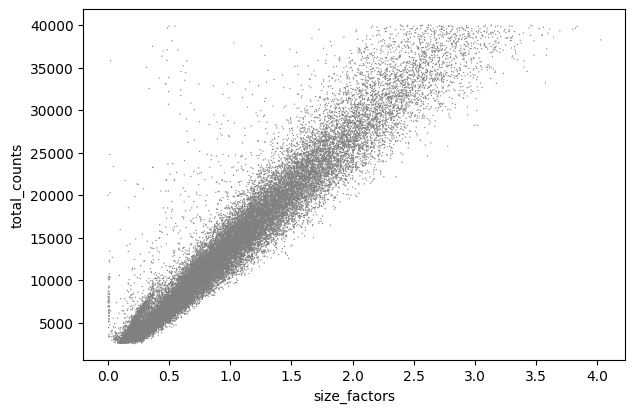

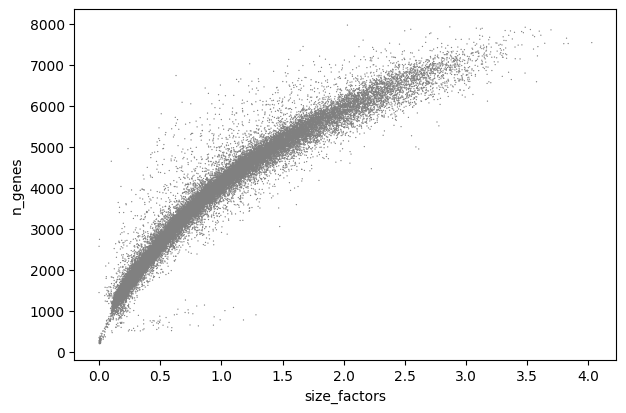

/tmp/ipykernel_1151126/1409471852.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(size_factors, bins=50, kde=False)


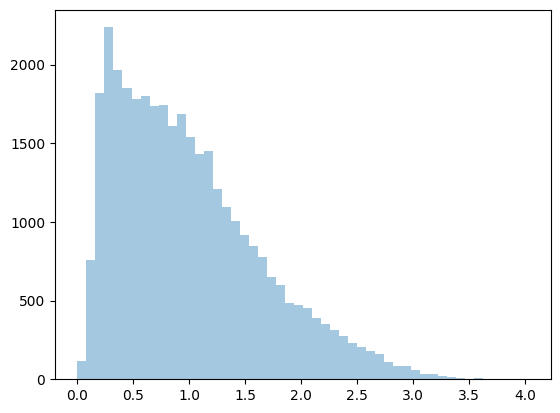

In [26]:
# Visualize the estimated size factors
adata.obs['size_factors'] = size_factors

sc.pl.scatter(adata, 'size_factors', 'total_counts')
sc.pl.scatter(adata, 'size_factors', 'n_genes')

sb.distplot(size_factors, bins=50, kde=False)
plt.show()

In [27]:
#Normalize adata 
adata.X /= adata.obs['size_factors'].values[:,None]
sc.pp.log1p(adata)

In [28]:
# high variable genes selection
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=False)

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']


In [29]:
adata.write("/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-perannot-unify-decontXcounts.h5ad")

In [30]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-perannot-unify-decontXcounts.h5ad")

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


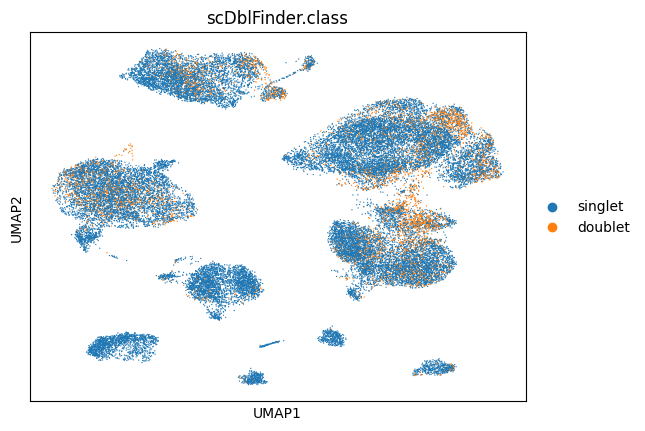

In [31]:
sc.pp.pca(adata, svd_solver="arpack", use_highly_variable=True)
sc.pp.neighbors(adata, n_pcs=30)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution = 2)
sc.pl.umap(adata, color= ['scDblFinder.class'], ncols=1)

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


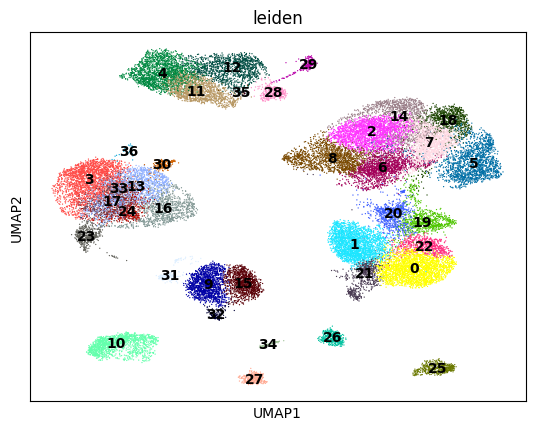

In [32]:
sc.pl.umap(adata, color= ['leiden'], ncols=1, legend_loc='on data')

In [ ]:
adata.var

In [ ]:
adata.obs_names_make_unique()
adata.var_names_make_unique()

In [ ]:
sc.pl.dotplot(
    adata,
    groupby="leiden",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
)

In [ ]:
##genes_mean
all_marker_genes = []
for gene_list in marker_genes_in_data.values():
    all_marker_genes.extend(gene_list)
all_marker_genes = [gene for gene in all_marker_genes if gene in adata.var_names]

all_marker_genes = list(set(all_marker_genes))
print(len(all_marker_genes))

In [ ]:
leiden_clusters = adata.obs["leiden"].cat.categories
mean_expression = np.zeros((len(leiden_clusters), len(all_marker_genes)))

for i, cluster in enumerate(leiden_clusters):
    cluster_cells = adata.obs["leiden"] == cluster
    cluster_adata = adata[cluster_cells, :]
    for j, gene in enumerate(all_marker_genes):
        mean_expression[i, j] = np.mean(cluster_adata[:, gene].X)

In [ ]:
df = pd.DataFrame(mean_expression, index=leiden_clusters, columns=all_marker_genes)
csv_file_path = '/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-gene_expression_mean(decontXcounts).csv'
df.to_csv(csv_file_path)
print(df)

In [ ]:
# 确保 df 和 ref_df 有共同的基因
common_genes = df.columns.intersection(ref_df.columns)
df = df[common_genes]
ref_df = ref_df[common_genes]

In [ ]:
##DISCO-CELLiD------coarse
from scipy.stats import spearmanr
first_round_results = {}
for cluster in df.index:
    cluster_expression = df.loc[cluster]
    correlations = []
    for ref_cell_type in ref_df.index:
        ref_expression = ref_df.loc[ref_cell_type]
        corr, _ = spearmanr(cluster_expression, ref_expression)
        correlations.append((ref_cell_type, corr))
    
    correlations.sort(key=lambda x: x[1], reverse=True)
    retained_types = [ct for ct, corr in correlations if corr > 0.6 or ct in [x[0] for x in correlations[:5]]]
    first_round_results[cluster] = retained_types

In [ ]:
##DISCO-CELLiD------fine

second_round_results = {}
for cluster, retained_types in first_round_results.items():
    if len(retained_types) > 0:
        retained_ref_df = ref_df.loc[retained_types]
        variances = retained_ref_df.var()
        top_genes = variances.nlargest(3000).index
        cluster_expression = df.loc[cluster][top_genes]
        retained_ref_df = retained_ref_df[top_genes]
        #spearmanr
        correlations = []
        for ref_cell_type in retained_types:
            ref_expression = retained_ref_df.loc[ref_cell_type]
            corr, _ = spearmanr(cluster_expression, ref_expression)
            correlations.append((ref_cell_type, corr))
        #the highest correlation
        best_cell_type = max(correlations, key=lambda x: x[1])[0]
        second_round_results[cluster] = best_cell_type
    else:
        second_round_results[cluster] = None
# result
print("细胞类型预测结果：")
for cluster, cell_type in second_round_results.items():
    print(f"细胞簇 {cluster} 的预测细胞类型：{cell_type}")

In [ ]:
# cluster_annotation1 = {
#     "0": "Neutrophil",
#     "1": "Foamy macrophage",
#     "2": "Smooth muscle cell",
#     "3": "Smooth muscle cell",
#     "4": "Smooth muscle cell",
#     "5": "Homeostatic/Resident macrophage",##or  Neutrophil
#     "6": "Fibroblast", ##or Pericyte
#     "7": "Fibroblast", ##or Pericyte
#     "8": "Pericyte",
#     "9": "Basophil",
#     "10": "Smooth muscle cell",
#     "11": "Basophil",
#     "12": "Fibroblast",
#     "13": "Arterial endothelial cell",##？
#     "14": "Homeostatic/Resident macrophage", ##or Basophil
#     "15": "Smooth muscle cell",
#     "16": "Neutrophil",
#     "17": "Fibroblast",
#     "18": "Homeostatic/Resident macrophage",
#     "19": "Smooth muscle cell",
#     "20": "Neutrophil",
#     "21": "Neutrophil",
#     "22": "Fibroblast",
#     "23": "Neutrophil",
#     "24": "Smooth muscle cell",
#     "25": "Fibroblast",
#     "26": "Neutrophil",
#     "27": "Fibroblast",
#     "28": "Fibroblast",
#     "29": "Basophil",
#     "30": "Neutrophil",
#     "31": "Neutrophil",
#     "32": "Neutrophil",
#     "33": "Neutrophil",
#     "34": "Fibroblast",
#     "35": "Fibroblast",
#     "36": "Smooth muscle cell",
#     "37": "Neutrophil",
#     "38": "Neutrophil",
#     "39": "B cell",
#     "40": "Erythrocyte/Erythroid",
#     "41": "Smooth muscle cell"
# }

cluster_annotation1 = {
    "0": "Fibroblast",
    "1": "Fibroblast",
    "2": "Smooth muscle cell",
    "3": "Homeostatic/Resident macrophage",
    "4": "Lymphatic endothelial cell",
    "5": "Pericyte",
    "6": "Smooth muscle cell", 
    "7": "Smooth muscle cell",
    "8": "Smooth muscle cell",
    "9": "T cell",
    "10": "Neutrophil",
    "11": "Lymphatic endothelial cell",
    "12": "Lymphatic endothelial cell", 
    "13": "Homeostatic/Resident macrophage",
    "14": "Smooth muscle cell",
    "15": "Natural killer cell",
    "16": "Homeostatic/Resident macrophage",
    "17": "Homeostatic/Resident macrophage",
    "18": "Homeostatic/Resident macrophage",
    "19": "Fibroblast",
    "20": "Fibroblast",
    "21": "Fibroblast", 
    "22": "Fibroblast",
    "23": "Monocyte",
    "24": "Homeostatic/Resident macrophage",
    "25": "Lymphatic endothelial cell",
    "26": "Fibroblast",
    "27": "Basophil",
    "28": "Lymphatic endothelial cell",
    "29": "Lymphatic endothelial cell",
    "30": "Homeostatic/Resident macrophage", 
    "31": "B cell",
    "32": "Neutrophil",
    "33": "Homeostatic/Resident macrophage",
    "34": "Erythrocyte/Erythroid",
    "35": "Lymphatic endothelial cell",
    "36": "Homeostatic/Resident macrophage"
}

In [ ]:
adata.obs["cell_type_level1"] = adata.obs.leiden.map(cluster_annotation1)

In [ ]:
sc.pl.umap(adata, color= ['cell_type_level1'],ncols=1)

In [ ]:
adata.write_h5ad("/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-annot-2-r2--2-decontXcounts.h5ad")

# CELLXGENE   sample_name = Tabula Sapiens-Vasculature

In [33]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-prepostQC-unify.h5ad")

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [34]:
adata

AnnData object with n_obs × n_vars = 39480 × 61759
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue'
    var: 'mt', 'ensembl_id'

In [35]:
adata.obs['sample'].value_counts()

sample
Tabula Sapiens-Vasculature    39480
Name: count, dtype: int64

In [36]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1151126/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [37]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-prepostQC-unify.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
sce1 <- scDblFinder(sce, samples=samples)
sce2 <- decontX(sce1, batch = samples)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-postR-unify.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:1900: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:1900: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


--------------------------------------------------
Starting DecontX
--------------------------------------------------
Mon Nov 17 15:34:07 2025 .. Analyzing all cells
Mon Nov 17 15:34:08 2025 .... Generating UMAP and estimating cell types
Mon Nov 17 15:35:54 2025 .... Estimating contamination
Mon Nov 17 15:36:33 2025 ...... Completed iteration: 10 | converge: 0.02874
Mon Nov 17 15:37:06 2025 ...... Completed iteration: 20 | converge: 0.01073
Mon Nov 17 15:37:39 2025 ...... Completed iteration: 30 | converge: 0.004803
Mon Nov 17 15:38:13 2025 ...... Completed iteration: 40 | converge: 0.003131
Mon Nov 17 15:38:47 2025 ...... Completed iteration: 50 | converge: 0.002317
Mon Nov 17 15:39:20 2025 ...... Completed iteration: 60 | converge: 0.001989
Mon Nov 17 15:39:55 2025 ...... Completed iteration: 70 | converge: 0.001676
Mon Nov 17 15:40:29 2025 ...... Completed iteration: 80 | converge: 0.001296
Mon Nov 17 15:40:47 2025 ...... Completed iteration: 85 | converge: 0.0009775
Mon Nov 17 15:

In [38]:
##这个是之前的，样本名字为Tabula Sapiens-Vasculature
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-postR-unify.h5ad")
adata

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 39480 × 61759
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'mt', 'ensembl_id'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [39]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [40]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=100)  
sc.pp.filter_cells(adata, max_genes = 8000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 40000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 39480


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Number of cells after filter: 38620
Number of cells before MT filter: 35890
Number of cells after MT filter: 34612


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [41]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_1151126/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 34612 × 46817
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'mt', 'ensembl_id', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [42]:
adata.write("/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-postQC-unify.h5ad")

# CELLxGENE 39480 34612

In [10]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-prepostQC-1.h5ad")

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [11]:
adata

AnnData object with n_obs × n_vars = 39480 × 61759
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue'
    var: 'mt', 'ensembl_id'

In [12]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_3477479/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [15]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-prepostQC-1.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL

sample_counts <- table(sce$sample)
keep_samples <- names(sample_counts)[sample_counts >= 10]  # 保留细胞数 >=10 的样本
sce_filtered <- sce[, sce$sample %in% keep_samples]
sce1 <- scDblFinder(sce_filtered, samples = sce_filtered$sample)

# sce1 <- scDblFinder(sce, samples=samples)
sce2 <- decontX(sce1, batch = samples)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-postR-1.h5ad")

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:1900: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


--------------------------------------------------
Starting DecontX
--------------------------------------------------
Tue Nov 11 21:22:31 2025 .. Analyzing cells in batch 'TSP2_Vasculature_Aorta_SS2_B114577_B133059_Endothelial'
Tue Nov 11 21:22:32 2025 .... Generating UMAP and estimating cell types
Tue Nov 11 21:22:36 2025 .... Estimating contamination
Tue Nov 11 21:22:36 2025 ...... Completed iteration: 10 | converge: 0.01444
Tue Nov 11 21:22:36 2025 ...... Completed iteration: 20 | converge: 0.00348
Tue Nov 11 21:22:36 2025 ...... Completed iteration: 30 | converge: 0.001754
Tue Nov 11 21:22:36 2025 ...... Completed iteration: 40 | converge: 0.001078
Tue Nov 11 21:22:36 2025 ...... Completed iteration: 42 | converge: 0.0009606
Tue Nov 11 21:22:36 2025 .. Calculating final decontaminated matrix
Tue Nov 11 21:22:37 2025 .. Analyzing cells in batch 'TSP2_Vasculature_Aorta_SS2_B114585_B133324_Stromal'
Tue Nov 11 21:22:37 2025 .... Generating UMAP and estimating cell types
Tue Nov 11 21:

RInterpreterError: Failed to parse and evaluate line 'library(celda)\nlibrary(zellkonverter)\nlibrary(SummarizedExperiment)\nlibrary(scDblFinder)\nsce = readH5AD("/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-prepostQC-1.h5ad")\nsamples = sce$sample\nassays(sce)$counts <- assays(sce)$X\nassays(sce)$X <- NULL\n\nsample_counts <- table(sce$sample)\nkeep_samples <- names(sample_counts)[sample_counts >= 10]  # 保留细胞数 >=10 的样本\nsce_filtered <- sce[, sce$sample %in% keep_samples]\nsce1 <- scDblFinder(sce_filtered, samples = sce_filtered$sample)\n\n# sce1 <- scDblFinder(sce, samples=samples,n_neighbors = 5)\nsce2 <- decontX(sce1, batch = samples)\nsce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-postR-1.h5ad")\n'.
R error message: 'Error in uwot(X = X, n_neighbors = n_neighbors, n_components = n_components,  : \n  n_neighbors must be smaller than the dataset size'
R stdout:
-------------

In [11]:
##这个是之前的，样本名字为Tabula Sapiens-Vasculature
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-postR.h5ad")
adata

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 39480 × 61759
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'mt', 'ensembl_id'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'decontXcounts'

In [12]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [13]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=100)  
sc.pp.filter_cells(adata, max_genes = 8000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 40000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))

Number of cells before filter: 39480


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Number of cells after filter: 38620
Number of cells before MT filter: 35890
Number of cells after MT filter: 34612


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [14]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_3414795/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 34612 × 46817
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'mt', 'ensembl_id', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [15]:
adata.write("/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/cellbygene_TS_Vasculature-postQC.h5ad")

# Bleckwehl et al. 62398 59806

HCA:17554 14513(include)

In [4]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/Article_SC_healthy_ensembl_id-prepostQC.h5ad")

In [5]:
adata

AnnData object with n_obs × n_vars = 62398 × 7998
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue'
    var: 'ensembl_id'

In [6]:
adata.obs['sample'].value_counts()

sample
S2    26812
S1    19386
S3    16200
Name: count, dtype: int64

In [7]:
# Start with doublet removal and ambient RNA correction
import anndata2ri
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc

rcb.logger.setLevel(logging.ERROR)
ro.pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

/tmp/ipykernel_606262/2937564426.py:10: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [8]:
%%R 
library(celda)
library(zellkonverter)
library(SummarizedExperiment)
library(scDblFinder)
sce = readH5AD("/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/Article_SC_healthy_ensembl_id-prepostQC.h5ad")
samples = sce$sample
assays(sce)$counts <- assays(sce)$X
assays(sce)$X <- NULL
sce1 <- scDblFinder(sce, samples=samples)
sce2 <- decontX(sce1, batch = samples)
sce_adata <- writeH5AD(sce2, file="/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/Article_SC_healthy_ensembl_id-postR.h5ad")


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

/home/lixiangyu/.cache/R/basilisk/1.14.3/zellkonverter/1.12.1/zellkonverterAnnDataEnv-0.10.2/lib/python3.11/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


Loading required package: SingleCellExperiment
Loading required package: SummarizedExperiment
Loading required package: MatrixGenerics
Loading required package: matrixStats

Attaching package: ‘MatrixGenerics’

The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOr

In [9]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/Article_SC_healthy_ensembl_id-postR.h5ad")
adata

AnnData object with n_obs × n_vars = 62398 × 7998
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters'
    var: 'ensembl_id'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_S1_UMAP', 'decontX_S2_UMAP', 'decontX_S3_UMAP'
    layers: 'decontXcounts'

In [10]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # annotate the group of mitochondrial genes as 'mt'
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [11]:
print('Number of cells before filter: {:d}'.format(adata.n_obs))

sc.pp.filter_cells(adata, min_genes=100)  
sc.pp.filter_cells(adata, max_genes = 8000)  
sc.pp.filter_genes(adata, min_cells=3)
print('Number of cells after filter: {:d}'.format(adata.n_obs))
sc.pp.filter_cells(adata, max_counts = 25000)
print('Number of cells before MT filter: {:d}'.format(adata.n_obs))

adata = adata[adata.obs['pct_counts_mt'] < 15] 
print('Number of cells after MT filter: {:d}'.format(adata.n_obs))


Number of cells before filter: 62398
Number of cells after filter: 62360
Number of cells before MT filter: 62354
Number of cells after MT filter: 59806


In [12]:
adata.layers["uncorrected_counts"] = adata.X.copy()
adata.layers["raw_decontXcounts"] = adata.layers["decontXcounts"].copy()
adata.X = np.around(adata.layers["raw_decontXcounts"].copy()).astype(int)
del adata.layers["decontXcounts"]
adata

/tmp/ipykernel_606262/191121921.py:1: ImplicitModificationWarning: Setting element `.layers['uncorrected_counts']` of view, initializing view as actual.
  adata.layers["uncorrected_counts"] = adata.X.copy()


AnnData object with n_obs × n_vars = 59806 × 7754
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts'
    var: 'ensembl_id', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'X_name', 'decontX', 'scDblFinder.threshold'
    obsm: 'decontX_S1_UMAP', 'decontX_S2_UMAP', 'decontX_S3_UMAP'
    layers: 'uncorrected_counts', 'raw_decontXcounts'

In [13]:
adata.write("/home/lixiangyu/zr/Annotate/output_data/public_data/Bleckwehl_et_al/Bleckwehl_et_al_postQC.h5ad")

In [304]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/output_data/public_data/Bleckwehl_et_al/Bleckwehl_et_al_postQC.h5ad")

In [305]:
adata.obs['sample'].value_counts()

sample
S2    26323
S1    17690
S3    15793
Name: count, dtype: int64

# End